### Oczyść Dane

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('halfmarathon_wroclaw_2023__final.csv', sep=';')

def convert_time_to_seconds(time):
    if pd.isnull(time) or time in ['DNS', 'DNF']:
        return None
    time = time.split(':')
    return int(time[0]) * 3600 + int(time[1]) * 60 + int(time[2])

df['Czas'] = df['Czas'].apply(convert_time_to_seconds)

df['Czas'].head()

0    3899.0
1    3983.0
2    4104.0
3    4216.0
4    4227.0
Name: Czas, dtype: float64

In [3]:
df.head()

,Miejsce,Numer startowy,Imię,Nazwisko,Miasto,Kraj,Drużyna,Płeć,Płeć Miejsce,Kategoria wiekowa,...,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
0,1.0,1787,TOMASZ,GRYCKO,NaN,POL,UKS BLIZA WŁADYSŁAWOWO,M,1.0,M30,...,2.926667,00:44:47,1.0,3.106667,01:01:43,1.0,3.386667,0.031400,3899.0,3.080509
1,2.0,3,ARKADIUSZ,GARDZIELEWSKI,WROCŁAW,POL,ARKADIUSZGARDZIELEWSKI.PL,M,2.0,M30,...,2.983333,00:45:26,2.0,3.143333,01:03:08,2.0,3.540000,0.038000,3983.0,3.146875
2,3.0,3832,KRZYSZTOF,HADAS,POZNAŃ,POL,NaN,M,3.0,M20,...,3.123333,00:47:34,3.0,3.236667,01:05:09,3.0,3.516667,0.024067,4104.0,3.242475
3,4.0,416,DAMIAN,DYDUCH,KĘPNO,POL,AZS POLITECHNIKA OPOLSKA,M,4.0,M30,...,3.196667,00:48:49,5.0,3.330000,01:06:54,4.0,3.616667,0.025467,4216.0,3.330963
4,5.0,8476,KAMIL,MAŃKOWSKI,MIRKÓW,POL,PARKRUN WROCŁAW,M,5.0,M20,...,3.276667,00:49:31,7.0,3.386667,01:07:27,5.0,3.586667,0.023000,4227.0,3.339654


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Miejsce,8150.0,4075.500000,2352.846680,1.000000,2038.250000,4075.500000,6112.750000,8150.000000
Numer startowy,8950.0,4758.451732,2645.207126,1.000000,2504.250000,4770.500000,7010.750000,10000.000000
Płeć Miejsce,8150.0,2415.486626,1667.304693,1.000000,1019.250000,2038.000000,3791.750000,5829.000000
Kategoria wiekowa Miejsce,8141.0,649.992630,524.040520,1.000000,220.000000,517.000000,949.000000,1987.000000
Rocznik,8749.0,1980.938393,71.027734,0.000000,1977.000000,1984.000000,1991.000000,2006.000000
5 km Miejsce Open,8123.0,4070.677582,2350.132112,1.000000,2035.500000,4071.000000,6104.500000,8147.000000
5 km Tempo,8123.0,5.492411,0.807535,2.923333,4.936667,5.446667,6.016667,12.750000
10 km Miejsce Open,8139.0,4076.570586,2353.292768,1.000000,2038.500000,4076.000000,6113.500000,8156.000000
10 km Tempo,8116.0,5.536863,0.893716,2.926667,4.906667,5.456667,6.070833,9.753333
15 km Miejsce Open,8141.0,4075.617246,2352.375413,1.000000,2038.000000,4075.000000,6112.000000,8153.000000


In [5]:
df.columns

Index(['Miejsce', 'Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj',
       'Drużyna', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa',
       'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')

In [6]:
df.isnull().sum()

Miejsce                       800
Numer startowy                  0
Imię                            0
Nazwisko                        0
Miasto                       1089
Kraj                          800
Drużyna                      5529
Płeć                            2
Płeć Miejsce                  800
Kategoria wiekowa              11
Kategoria wiekowa Miejsce     809
Rocznik                       201
5 km Czas                     827
5 km Miejsce Open             827
5 km Tempo                    827
10 km Czas                    811
10 km Miejsce Open            811
10 km Tempo                   834
15 km Czas                    809
15 km Miejsce Open            809
15 km Tempo                   814
20 km Czas                    806
20 km Miejsce Open            806
20 km Tempo                   813
Tempo Stabilność              840
Czas                          800
Tempo                         800
dtype: int64

### Usuwamy osoby które nie przebiegły nawet 5 km -  kolumna `5 km Czas` równa 'None'  
##### ( musimy je odrzucić ponieważ nie są one reprezentatywne jeżeli pytamy użytkownika o czas na 5 km )
#####  Są to 'głównie' osoby które też nie dobiegły na metę.

In [7]:
df = df.dropna(subset=['5 km Czas'])

In [8]:
df.isnull().sum()

Miejsce                         0
Numer startowy                  0
Imię                            0
Nazwisko                        0
Miasto                        288
Kraj                            0
Drużyna                      5007
Płeć                            0
Płeć Miejsce                    0
Kategoria wiekowa               9
Kategoria wiekowa Miejsce       9
Rocznik                       200
5 km Czas                       0
5 km Miejsce Open               0
5 km Tempo                      0
10 km Czas                      7
10 km Miejsce Open              7
10 km Tempo                     7
15 km Czas                      6
15 km Miejsce Open              6
15 km Tempo                    10
20 km Czas                      5
20 km Miejsce Open              5
20 km Tempo                    10
Tempo Stabilność               13
Czas                            0
Tempo                           0
dtype: int64

In [9]:
columns_to_drop = ['Numer startowy', 'Imię', 'Nazwisko', 'Miasto', 'Kraj', 'Drużyna']
df = df.drop(columns=columns_to_drop)
df.columns


Index(['Miejsce', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa',
       'Kategoria wiekowa Miejsce', 'Rocznik', '5 km Czas',
       '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open',
       '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
       '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność',
       'Czas', 'Tempo'],
      dtype='object')

In [10]:
pd.set_option('display.max_columns', None) 
df[df['Rocznik'].isna()].head(20)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
79,80.0,M,77.0,M40,25.0,NaN,00:18:35,57.0,3.716667,00:37:08,60.0,3.710000,00:56:38,61.0,3.900000,01:18:10,75.0,4.306667,0.039200,4931.0,3.895868
173,174.0,M,165.0,M40,57.0,NaN,00:20:13,224.0,4.043333,00:40:03,215.0,3.966667,01:00:40,196.0,4.123333,01:22:41,175.0,4.403333,0.024733,5205.0,4.112349
538,539.0,M,505.0,M30,196.0,NaN,00:22:37,844.0,4.523333,00:44:41,772.0,4.413333,01:06:47,640.0,4.420000,01:30:17,550.0,4.700000,0.010733,5670.0,4.479735
543,544.0,M,510.0,M30,197.0,NaN,00:20:58,390.0,4.193333,00:42:19,455.0,4.270000,01:04:34,455.0,4.450000,01:29:44,519.0,5.033333,0.054000,5679.0,4.486845
626,627.0,M,586.0,M30,230.0,NaN,00:23:18,1175.0,4.660000,00:45:34,950.0,4.453333,01:08:22,802.0,4.560000,01:31:58,655.0,4.720000,0.005733,5757.0,4.548471
670,671.0,M,625.0,M30,253.0,NaN,00:22:19,745.0,4.463333,00:44:23,731.0,4.413333,01:07:29,711.0,4.620000,01:32:20,680.0,4.970000,0.034533,5805.0,4.586395
1086,1087.0,M,1005.0,M20,151.0,NaN,00:24:41,2032.0,4.936667,00:48:26,1756.0,4.750000,01:12:27,1452.0,4.803333,01:37:12,1142.0,4.950000,0.001867,6083.0,4.806036
1150,1151.0,M,1063.0,M30,406.0,NaN,00:24:00,1528.0,4.800000,00:47:37,1462.0,4.723333,01:11:55,1351.0,4.860000,01:37:22,1164.0,5.090000,0.020133,6122.0,4.836849
1162,1163.0,K,90.0,K40,24.0,NaN,00:21:36,525.0,4.320000,00:43:55,668.0,4.463333,01:07:58,760.0,4.810000,01:36:25,1058.0,5.690000,0.089133,6125.0,4.839219
1185,1186.0,M,1095.0,M20,172.0,NaN,00:23:33,1269.0,4.710000,00:47:24,1394.0,4.770000,01:11:29,1275.0,4.816667,01:37:31,1182.0,5.206667,0.030733,6141.0,4.851861


In [11]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              9
Kategoria wiekowa Miejsce      9
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     7
10 km Miejsce Open             7
10 km Tempo                    7
15 km Czas                     6
15 km Miejsce Open             6
15 km Tempo                   10
20 km Czas                     5
20 km Miejsce Open             5
20 km Tempo                   10
Tempo Stabilność              13
Czas                           0
Tempo                          0
dtype: int64

In [12]:
df[df['Kategoria wiekowa'].isna()].head(20)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
243,244.0,M,233.0,NaN,NaN,0.0,00:21:00,397.0,4.200000,00:40:36,244.0,3.920000,01:01:12,219.0,4.120000,01:24:17,240.0,4.616667,0.029000,5308.0,4.193727
245,246.0,M,235.0,NaN,NaN,0.0,00:20:28,257.0,4.093333,00:40:48,264.0,4.066667,01:02:05,283.0,4.256667,01:24:41,257.0,4.520000,0.029400,5310.0,4.195307
845,846.0,M,790.0,NaN,NaN,0.0,00:21:54,610.0,4.380000,00:43:42,627.0,4.360000,01:07:44,739.0,4.806667,01:34:07,820.0,5.276667,0.062733,5936.0,4.689895
1262,1263.0,M,1165.0,NaN,NaN,0.0,00:25:05,2320.0,5.016667,00:49:19,2081.0,4.846667,01:13:17,1645.0,4.793333,01:38:33,1309.0,5.053333,0.001133,6178.0,4.881093
2165,2166.0,M,1956.0,NaN,NaN,0.0,00:25:55,2952.0,5.183333,00:50:51,2599.0,4.986667,01:16:46,2438.0,5.183333,01:44:22,2221.0,5.520000,0.024133,6547.0,5.172632
4795,4796.0,M,3939.0,NaN,NaN,0.0,00:28:47,5342.0,5.756667,00:57:17,5197.0,5.700000,01:27:00,5086.0,5.943333,01:58:38,4797.0,6.326667,0.039067,7467.0,5.899502
6336,6337.0,M,4899.0,NaN,NaN,0.0,00:29:26,5725.0,5.886667,00:59:47,5952.0,6.070000,01:32:03,6060.0,6.453333,02:09:57,6286.0,7.580000,0.109267,8221.0,6.495220
8018,8019.0,M,5763.0,NaN,NaN,0.0,00:36:31,8038.0,7.303333,01:16:38,8085.0,8.023333,01:57:11,8048.0,8.110000,02:43:58,8021.0,9.356667,0.124933,10348.0,8.175713
8066,8067.0,M,5787.0,NaN,NaN,0.0,00:38:53,8121.0,7.776667,01:19:34,8130.0,8.136667,NaN,NaN,NaN,02:47:52,8076.0,NaN,NaN,10555.0,8.339259


#### Musimy usunąć osoby nie posiadające danych o `roczniku` i `kategorii wiekowej` 
#### jednocześnie ,bo są to najważniejsze kolumny do predycji naszego modelu

In [13]:
df = df.dropna(subset=['Kategoria wiekowa'])

In [14]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     7
10 km Miejsce Open             7
10 km Tempo                    7
15 km Czas                     5
15 km Miejsce Open             5
15 km Tempo                    9
20 km Czas                     5
20 km Miejsce Open             5
20 km Tempo                    9
Tempo Stabilność              12
Czas                           0
Tempo                          0
dtype: int64

In [15]:
df[df['10 km Czas'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1050,1051.0,K,78.0,K40,19.0,1976.0,00:22:51,935.0,4.570000,NaN,NaN,NaN,01:10:27,1121.0,NaN,01:36:23,1052.0,5.186667,NaN,6066.0,4.792605
1203,1204.0,M,1111.0,M40,406.0,1981.0,00:28:29,5114.0,5.696667,NaN,NaN,NaN,NaN,NaN,NaN,01:36:38,1090.0,NaN,NaN,6147.0,4.856601
1591,1592.0,M,1460.0,M30,538.0,1985.0,00:24:56,2241.0,4.986667,NaN,NaN,NaN,01:13:48,1738.0,NaN,01:40:29,1591.0,5.336667,NaN,6324.0,4.996445
1901,1902.0,K,168.0,K30,69.0,1984.0,00:24:48,2129.0,4.960000,NaN,NaN,NaN,01:14:02,1807.0,NaN,NaN,NaN,NaN,NaN,6447.0,5.093624
4336,4337.0,K,721.0,K50,42.0,1967.0,00:53:00,8145.0,10.600000,NaN,NaN,NaN,NaN,NaN,NaN,01:54:02,3967.0,NaN,NaN,7287.0,5.757288
6637,6638.0,M,5056.0,M30,1670.0,1988.0,00:31:18,6699.0,6.260000,NaN,NaN,NaN,01:36:38,6682.0,NaN,02:13:56,6639.0,7.460000,NaN,8440.0,6.668247
7795,7796.0,K,2155.0,K30,792.0,1987.0,00:57:47,8146.0,11.556667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9664.0,7.635301


#### Brakujące dane w kolumnie `10 km czas` - 7 rekordów 
#### obliczamy za pomocą interpolacji mając dane z `5 km` i `15 km Czas`
#### Jeśli brak `15 km Czas`, używamy `5 km` i `20 km Czas`

In [16]:
def convert_time_to_seconds_safe(time):
    """Convert time string or numeric value to seconds"""
    if pd.isnull(time):
        return None
    if isinstance(time, (int, float)):
        return int(time)
    if time in ['DNS', 'DNF']:
        return None
    try:
        time_parts = str(time).split(':')
        return int(time_parts[0]) * 3600 + int(time_parts[1]) * 60 + int(time_parts[2])
    except:
        return None

if df['5 km Czas'].dtype == 'object':
    df['5 km Czas'] = df['5 km Czas'].apply(convert_time_to_seconds_safe)
if df['10 km Czas'].dtype == 'object':
    df['10 km Czas'] = df['10 km Czas'].apply(convert_time_to_seconds_safe)   
if df['15 km Czas'].dtype == 'object':
    df['15 km Czas'] = df['15 km Czas'].apply(convert_time_to_seconds_safe)
if df['20 km Czas'].dtype == 'object':
    df['20 km Czas'] = df['20 km Czas'].apply(convert_time_to_seconds_safe)



def interpolate_10km_time(row):
    if pd.notna(row['10 km Czas']):
        return row['10 km Czas']
    
    if pd.notna(row['5 km Czas']) and pd.notna(row['15 km Czas']):
        return ((row['5 km Czas'] + row['15 km Czas']) / 2)

    if pd.notna(row['5 km Czas']) and pd.notna(row['20 km Czas']):
        return row['5 km Czas'] + (row['20 km Czas'] - row['5 km Czas']) / 3
    
    return None

df['10 km Czas'] = df.apply(interpolate_10km_time, axis=1)

df['10 km Czas'] = df['10 km Czas'].apply(
    lambda x: int(x) if pd.notna(x) else None
)

df.isnull().sum()


Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     1
10 km Miejsce Open             7
10 km Tempo                    7
15 km Czas                     5
15 km Miejsce Open             5
15 km Tempo                    9
20 km Czas                     5
20 km Miejsce Open             5
20 km Tempo                    9
Tempo Stabilność              12
Czas                           0
Tempo                          0
dtype: int64

#### Usuwamy rekord z miejscem 7796 ,ponieważ ma on czas tylko 5km i końcowy więc interpolacja nie jest sensowna

In [17]:
df = df[df['Miejsce'] != 7796]

df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             6
10 km Tempo                    6
15 km Czas                     4
15 km Miejsce Open             4
15 km Tempo                    8
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [18]:
df[df['10 km Tempo'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1050,1051.0,K,78.0,K40,19.0,1976.0,1371,935.0,4.570000,2799.0,NaN,NaN,4227.0,1121.0,NaN,5783.0,1052.0,5.186667,NaN,6066.0,4.792605
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,5.696667,3072.0,NaN,NaN,NaN,NaN,NaN,5798.0,1090.0,NaN,NaN,6147.0,4.856601
1591,1592.0,M,1460.0,M30,538.0,1985.0,1496,2241.0,4.986667,2962.0,NaN,NaN,4428.0,1738.0,NaN,6029.0,1591.0,5.336667,NaN,6324.0,4.996445
1901,1902.0,K,168.0,K30,69.0,1984.0,1488,2129.0,4.960000,2965.0,NaN,NaN,4442.0,1807.0,NaN,NaN,NaN,NaN,NaN,6447.0,5.093624
4336,4337.0,K,721.0,K50,42.0,1967.0,3180,8145.0,10.600000,4400.0,NaN,NaN,NaN,NaN,NaN,6842.0,3967.0,NaN,NaN,7287.0,5.757288
6637,6638.0,M,5056.0,M30,1670.0,1988.0,1878,6699.0,6.260000,3838.0,NaN,NaN,5798.0,6682.0,NaN,8036.0,6639.0,7.460000,NaN,8440.0,6.668247


#### Na podobnej zasadzie wypełniany 6 rekordów z brakiem w `10 km Tempo`

In [19]:
def calculate_tempo_from_time(time_in_seconds, distance_km):
    """Oblicza tempo (czas na 1 km) z czasu i dystansu"""
    if pd.isnull(time_in_seconds):
        return None
    tempo_seconds = time_in_seconds / distance_km
    minutes = int(tempo_seconds // 60)
    seconds = int(tempo_seconds % 60)
    return f"{minutes}:{seconds:02d}"


df['10 km Tempo'] = df.apply(
    lambda row: calculate_tempo_from_time(row['10 km Czas'], 10) if pd.isna(row['10 km Tempo']) else row['10 km Tempo'],
    axis=1
)


df['15 km Tempo'] = df.apply(
    lambda row: calculate_tempo_from_time(row['15 km Czas'], 15) if pd.isna(row['15 km Tempo']) else row['15 km Tempo'],
    axis=1
)


df[df['10 km Tempo'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo


In [20]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             6
10 km Tempo                    0
15 km Czas                     4
15 km Miejsce Open             4
15 km Tempo                    4
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [21]:
def convert_tempo_to_decimal(tempo):
    """Konwertuje tempo z formatu mm:ss na liczbę dziesiętną (minuty)"""
    if pd.isna(tempo) or tempo is None:
        return None
    if isinstance(tempo, (int, float)):
        
        return round(float(tempo), 6)
    
    
    try:
        parts = str(tempo).split(':')
        minutes = int(parts[0])
        seconds = int(parts[1])
        decimal_tempo = minutes + (seconds / 60)
        return round(decimal_tempo, 6)
    except:
        return None

tempo_columns = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']

for col in tempo_columns:
    if col in df.columns:
        df[col] = df[col].apply(convert_tempo_to_decimal)

df[tempo_columns].head(20)


,5 km Tempo,10 km Tempo,15 km Tempo,20 km Tempo
0,2.923333,2.926667,3.106667,3.386667
1,2.960000,2.983333,3.143333,3.540000
2,3.153333,3.123333,3.236667,3.516667
3,3.236667,3.196667,3.330000,3.616667
4,3.240000,3.276667,3.386667,3.586667
5,3.230000,3.270000,3.403333,3.590000
6,3.123333,3.160000,3.376667,3.866667
7,3.300000,3.283333,3.406667,3.670000
8,3.433333,3.443333,3.560000,3.773333
9,3.376667,3.406667,3.546667,3.836667


In [22]:
print("=" * 100)
print("KONWERSJA JEDNOSTEK TEMPA: min/km → sek/km (poprawiona)")
print("=" * 100)

tempo_columns_to_convert = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']

def tempo_to_seconds(val):
    if pd.isnull(val):
        return None
    if isinstance(val, (int, float)):
        
        if 100 < val < 500:
            return val
        
        return val * 60
    if isinstance(val, str):
        
        parts = val.split(":")
        if len(parts) == 2:
            try:
                return int(parts[0]) * 60 + int(parts[1])
            except:
                return None
        try:
            return float(val)
        except:
            return None
    return None

print("\nPRZED konwersją (przykład - 5 rekordów):")
print(df[tempo_columns_to_convert].head())

for col in tempo_columns_to_convert:
    df[col] = df[col].apply(tempo_to_seconds)
    df[col] = df[col].apply(lambda x: round(x, 2) if pd.notna(x) else None)

print("\nPO konwersji (przykład - 5 rekordów):")
print(df[tempo_columns_to_convert].head())

print("\n" + "=" * 100)
print("STATUS KONWERSJI:")
print("=" * 100)
for col in tempo_columns_to_convert:
    print(f"✓ {col}: min/km → sek/km (poprawnie)")
print(f"✓ Tempo Stabilność: bez zmian (min/km)")

print("\n" + "=" * 100)
print("PORÓWNANIE PRZED I PO (rekordy 1-5):")
print("=" * 100)
print(df.head()[[
    'Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo', 'Tempo Stabilność'
]])


KONWERSJA JEDNOSTEK TEMPA: min/km → sek/km (poprawiona)

PRZED konwersją (przykład - 5 rekordów):
   5 km Tempo  10 km Tempo  15 km Tempo  20 km Tempo
0    2.923333     2.926667     3.106667     3.386667
1    2.960000     2.983333     3.143333     3.540000
2    3.153333     3.123333     3.236667     3.516667
3    3.236667     3.196667     3.330000     3.616667
4    3.240000     3.276667     3.386667     3.586667

PO konwersji (przykład - 5 rekordów):
   5 km Tempo  10 km Tempo  15 km Tempo  20 km Tempo
0       175.4        175.6        186.4        203.2
1       177.6        179.0        188.6        212.4
2       189.2        187.4        194.2        211.0
3       194.2        191.8        199.8        217.0
4       194.4        196.6        203.2        215.2

STATUS KONWERSJI:
✓ 5 km Tempo: min/km → sek/km (poprawnie)
✓ 10 km Tempo: min/km → sek/km (poprawnie)
✓ 15 km Tempo: min/km → sek/km (poprawnie)
✓ 20 km Tempo: min/km → sek/km (poprawnie)
✓ Tempo Stabilność: bez zmian (min/km

#### Teraz próbujemy zaadresować 6 braków w kolumnie `10 km Miejsce Open`

In [23]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             6
10 km Tempo                    0
15 km Czas                     4
15 km Miejsce Open             4
15 km Tempo                    4
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [24]:
df[df['10 km Miejsce Open'].isna()].head(10)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1050,1051.0,K,78.0,K40,19.0,1976.0,1371,935.0,274.2,2799.0,NaN,279.0,4227.0,1121.0,281.0,5783.0,1052.0,311.2,NaN,6066.0,4.792605
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,341.8,3072.0,NaN,307.0,NaN,NaN,NaN,5798.0,1090.0,NaN,NaN,6147.0,4.856601
1591,1592.0,M,1460.0,M30,538.0,1985.0,1496,2241.0,299.2,2962.0,NaN,296.0,4428.0,1738.0,295.0,6029.0,1591.0,320.2,NaN,6324.0,4.996445
1901,1902.0,K,168.0,K30,69.0,1984.0,1488,2129.0,297.6,2965.0,NaN,296.0,4442.0,1807.0,296.0,NaN,NaN,NaN,NaN,6447.0,5.093624
4336,4337.0,K,721.0,K50,42.0,1967.0,3180,8145.0,636.0,4400.0,NaN,440.0,NaN,NaN,NaN,6842.0,3967.0,NaN,NaN,7287.0,5.757288
6637,6638.0,M,5056.0,M30,1670.0,1988.0,1878,6699.0,375.6,3838.0,NaN,383.0,5798.0,6682.0,386.0,8036.0,6639.0,447.6,NaN,8440.0,6.668247


#### Automatyczne wypełnianie brakujących miejsc na 10 km
Strategia: dla każdego brakującego miejsca, znajdź zawodników z podobnym czasem (w przedziale ±4 sekund) i przypisz średnią ich miejsc


In [25]:
df_original = df.copy()

missing_places = df[df['10 km Miejsce Open'].isna()].copy()

print(f"Liczba rekordów z brakującym '10 km Miejsce Open': {len(missing_places)}")
print(f"\nCzasy dla brakujących miejsc:")
print(missing_places[['Miejsce', '10 km Czas', '10 km Miejsce Open']].sort_values('10 km Czas'))

Liczba rekordów z brakującym '10 km Miejsce Open': 6

Czasy dla brakujących miejsc:
      Miejsce  10 km Czas  10 km Miejsce Open
1050   1051.0      2799.0                 NaN
1591   1592.0      2962.0                 NaN
1901   1902.0      2965.0                 NaN
1203   1204.0      3072.0                 NaN
6637   6638.0      3838.0                 NaN
4336   4337.0      4400.0                 NaN


In [26]:
def fill_missing_10km_place(row, df_full, time_range=4):
    """
    Wypełnia brakujące miejsce na 10 km na podstawie zawodników z podobnym czasem.
    
    Parameters:
    - row: wiersz z brakującym miejscem
    - df_full: pełny dataframe ze wszystkimi zawodnikami
    - time_range: zakres czasu w sekundach (±4 sekundy domyślnie)
    
    Returns:
    - miejsce zaokrąglone do najbliższej liczby całkowitej
    """
    time_10km = row['10 km Czas']
    
    if pd.isna(time_10km):
        return None
    
    similar_athletes = df_full[
        (df_full['10 km Czas'].notna()) &
        (df_full['10 km Miejsce Open'].notna()) &
        (df_full['10 km Czas'] >= time_10km - time_range) &
        (df_full['10 km Czas'] <= time_10km + time_range)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['10 km Miejsce Open'].mean()
        return round(avg_place)
    
    similar_athletes = df_full[
        (df_full['10 km Czas'].notna()) &
        (df_full['10 km Miejsce Open'].notna()) &
        (df_full['10 km Czas'] >= time_10km - 10) &
        (df_full['10 km Czas'] <= time_10km + 10)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['10 km Miejsce Open'].mean()
        return round(avg_place)
    
    return None

df_original = df.copy()

df['10 km Miejsce Open'] = df.apply(
    lambda row: fill_missing_10km_place(row, df) if pd.isna(row['10 km Miejsce Open']) else row['10 km Miejsce Open'],
    axis=1
)

print(f"Brakujące wartości po interpolacji: {df['10 km Miejsce Open'].isna().sum()}")
print(f"\nWypełnione rekordy:")
filled_indices = df_original[df_original['10 km Miejsce Open'].isna()].index
print(df.loc[filled_indices][['Miejsce', '10 km Czas', '10 km Miejsce Open']].sort_values('10 km Czas'))

Brakujące wartości po interpolacji: 0

Wypełnione rekordy:
      Miejsce  10 km Czas  10 km Miejsce Open
1050   1051.0      2799.0              1215.0
1591   1592.0      2962.0              2099.0
1901   1902.0      2965.0              2117.0
1203   1204.0      3072.0              2741.0
6637   6638.0      3838.0              6869.0
4336   4337.0      4400.0              7980.0


In [27]:
df.loc[df['Miejsce'] ==  1204 ]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,341.8,3072.0,2741.0,307.0,NaN,NaN,NaN,5798.0,1090.0,NaN,NaN,6147.0,4.856601


In [28]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     4
15 km Miejsce Open             4
15 km Tempo                    4
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [29]:
df[df['15 km Czas'].isna()].head(15)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,341.8,3072.0,2741.0,307.0,NaN,NaN,NaN,5798.0,1090.0,NaN,NaN,6147.0,4.856601
4336,4337.0,K,721.0,K50,42.0,1967.0,3180,8145.0,636.0,4400.0,7980.0,440.0,NaN,NaN,NaN,6842.0,3967.0,NaN,NaN,7287.0,5.757288
4746,4747.0,M,3903.0,M40,1383.0,1980.0,1597,3499.0,319.4,3269.0,4047.0,334.4,NaN,NaN,NaN,7074.0,4676.0,NaN,NaN,7450.0,5.886071
8047,8048.0,M,5776.0,M50,636.0,1965.0,2163,7993.0,432.6,4437.0,8008.0,454.8,NaN,NaN,NaN,9820.0,8011.0,NaN,NaN,10451.0,8.257091


#### Uzupełnianie brakujących danych 15 km Czas
#### Interpolacja 10 z 20 km Czas


In [30]:
def interpolate_15km_time(row):
    """
    Interpoluje czas na 15 km na podstawie dostępnych danych.
    
    Strategia:
    1. Jeśli mamy 10 km i 20 km - używamy średniej (15 km jest w połowie)
    """
    if pd.notna(row['15 km Czas']):
        return row['15 km Czas']
    
    if pd.notna(row['10 km Czas']) and pd.notna(row['20 km Czas']):
        return (row['10 km Czas'] + row['20 km Czas']) / 2
    
    return None

df_original_15km = df.copy()

missing_15km = df[df['15 km Czas'].isna()].copy()
print(f"Liczba rekordów z brakującym '15 km Czas': {len(missing_15km)}")
print(f"\nRekordy przed interpolacją:")
print(missing_15km[['Miejsce', '5 km Czas', '10 km Czas', '15 km Czas', '20 km Czas', 'Czas']].sort_values('Miejsce'))

df['15 km Czas'] = df.apply(interpolate_15km_time, axis=1)

df['15 km Czas'] = df['15 km Czas'].apply(
    lambda x: int(x) if pd.notna(x) else None
)

print(f"\nBrakujące wartości po interpolacji: {df['15 km Czas'].isna().sum()}")
print(f"\nWypełnione rekordy:")
filled_indices = df_original_15km[df_original_15km['15 km Czas'].isna()].index
print(df.loc[filled_indices][['Miejsce', '5 km Czas', '10 km Czas', '15 km Czas', '20 km Czas', 'Czas']].sort_values('Miejsce'))

Liczba rekordów z brakującym '15 km Czas': 4

Rekordy przed interpolacją:
      Miejsce  5 km Czas  10 km Czas  15 km Czas  20 km Czas     Czas
1203   1204.0       1709      3072.0         NaN      5798.0   6147.0
4336   4337.0       3180      4400.0         NaN      6842.0   7287.0
4746   4747.0       1597      3269.0         NaN      7074.0   7450.0
8047   8048.0       2163      4437.0         NaN      9820.0  10451.0

Brakujące wartości po interpolacji: 0

Wypełnione rekordy:
      Miejsce  5 km Czas  10 km Czas  15 km Czas  20 km Czas     Czas
1203   1204.0       1709      3072.0        4435      5798.0   6147.0
4336   4337.0       3180      4400.0        5621      6842.0   7287.0
4746   4747.0       1597      3269.0        5171      7074.0   7450.0
8047   8048.0       2163      4437.0        7128      9820.0  10451.0


In [31]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             4
15 km Tempo                    4
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [32]:
df[df['15 km Miejsce Open'].isna()].head(15)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,341.8,3072.0,2741.0,307.0,4435,NaN,NaN,5798.0,1090.0,NaN,NaN,6147.0,4.856601
4336,4337.0,K,721.0,K50,42.0,1967.0,3180,8145.0,636.0,4400.0,7980.0,440.0,5621,NaN,NaN,6842.0,3967.0,NaN,NaN,7287.0,5.757288
4746,4747.0,M,3903.0,M40,1383.0,1980.0,1597,3499.0,319.4,3269.0,4047.0,334.4,5171,NaN,NaN,7074.0,4676.0,NaN,NaN,7450.0,5.886071
8047,8048.0,M,5776.0,M50,636.0,1965.0,2163,7993.0,432.6,4437.0,8008.0,454.8,7128,NaN,NaN,9820.0,8011.0,NaN,NaN,10451.0,8.257091


In [33]:
def fill_missing_15km_place(row, df_full, time_range=4):
    """
    Wypełnia brakujące miejsce na 15 km na podstawie zawodników z podobnym czasem.
    
    Parameters:
    - row: wiersz z brakującym miejscem
    - df_full: pełny dataframe ze wszystkimi zawodnikami
    - time_range: zakres czasu w sekundach (±4 sekundy domyślnie)
    
    Returns:
    - miejsce zaokrąglone do najbliższej liczby całkowitej
    """
    time_15km = row['15 km Czas']
    
    if pd.isna(time_15km):
        return None
    
    similar_athletes = df_full[
        (df_full['15 km Czas'].notna()) &
        (df_full['15 km Miejsce Open'].notna()) &
        (df_full['15 km Czas'] >= time_15km - time_range) &
        (df_full['15 km Czas'] <= time_15km + time_range)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['15 km Miejsce Open'].mean()
        return round(avg_place)
    
    similar_athletes = df_full[
        (df_full['15 km Czas'].notna()) &
        (df_full['15 km Miejsce Open'].notna()) &
        (df_full['15 km Czas'] >= time_15km - 10) &
        (df_full['15 km Czas'] <= time_15km + 10)
    ]
    
    if len(similar_athletes) > 0:
        avg_place = similar_athletes['15 km Miejsce Open'].mean()
        return round(avg_place)
    
    return None

df_original_15km_place = df.copy()

missing_15km_place = df[df['15 km Miejsce Open'].isna()].copy()
print(f"Liczba rekordów z brakującym '15 km Miejsce Open': {len(missing_15km_place)}")
print(f"\nCzasy dla brakujących miejsc:")
print(missing_15km_place[['Miejsce', '15 km Czas', '15 km Miejsce Open']].sort_values('15 km Czas'))

df['15 km Miejsce Open'] = df.apply(
    lambda row: fill_missing_15km_place(row, df) if pd.isna(row['15 km Miejsce Open']) else row['15 km Miejsce Open'],
    axis=1
)

print(f"\nBrakujące wartości po interpolacji: {df['15 km Miejsce Open'].isna().sum()}")
print(f"\nWypełnione rekordy:")
filled_indices = df_original_15km_place[df_original_15km_place['15 km Miejsce Open'].isna()].index
print(df.loc[filled_indices][['Miejsce', '15 km Czas', '15 km Miejsce Open']].sort_values('15 km Czas'))

Liczba rekordów z brakującym '15 km Miejsce Open': 4

Czasy dla brakujących miejsc:
      Miejsce  15 km Czas  15 km Miejsce Open
1203   1204.0        4435                 NaN
4746   4747.0        5171                 NaN
4336   4337.0        5621                 NaN
8047   8048.0        7128                 NaN

Brakujące wartości po interpolacji: 0

Wypełnione rekordy:
      Miejsce  15 km Czas  15 km Miejsce Open
1203   1204.0        4435              1769.0
4746   4747.0        5171              4912.0
4336   4337.0        5621              6306.0
8047   8048.0        7128              8075.0


In [34]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    4
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [35]:
def calculate_tempo_from_time(time_seconds, distance_km):
    """
    Oblicza tempo (sekundy na km) na podstawie czasu i dystansu.
    
    Parameters:
    - time_seconds: czas w sekundach
    - distance_km: dystans w kilometrach
    
    Returns:
    - tempo w sekundach na km
    """
    if pd.isna(time_seconds) or time_seconds <= 0:
        return None
    return time_seconds / distance_km

df_original_15km_tempo = df.copy()

missing_15km_tempo = df[df['15 km Tempo'].isna()].copy()
print(f"Liczba rekordów z brakującym '15 km Tempo': {len(missing_15km_tempo)}")
print(f"\nRekordy przed interpolacją:")
print(missing_15km_tempo[['Miejsce', '15 km Czas', '15 km Tempo']].sort_values('15 km Czas'))

df['15 km Tempo'] = df.apply(
    lambda row: calculate_tempo_from_time(row['15 km Czas'], 15) if pd.isna(row['15 km Tempo']) else row['15 km Tempo'],
    axis=1
)

df['15 km Tempo'] = df['15 km Tempo'].apply(
    lambda x: round(x, 1) if pd.notna(x) else None
)

print(f"\nBrakujące wartości po interpolacji: {df['15 km Tempo'].isna().sum()}")
print(f"\nWypełnione rekordy:")
filled_indices = df_original_15km_tempo[df_original_15km_tempo['15 km Tempo'].isna()].index
print(df.loc[filled_indices][['Miejsce', '15 km Czas', '15 km Tempo']].sort_values('15 km Czas'))

Liczba rekordów z brakującym '15 km Tempo': 4

Rekordy przed interpolacją:
      Miejsce  15 km Czas  15 km Tempo
1203   1204.0        4435          NaN
4746   4747.0        5171          NaN
4336   4337.0        5621          NaN
8047   8048.0        7128          NaN

Brakujące wartości po interpolacji: 0

Wypełnione rekordy:
      Miejsce  15 km Czas  15 km Tempo
1203   1204.0        4435        295.7
4746   4747.0        5171        344.7
4336   4337.0        5621        374.7
8047   8048.0        7128        475.2


In [36]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     4
20 km Miejsce Open             4
20 km Tempo                    8
Tempo Stabilność              11
Czas                           0
Tempo                          0
dtype: int64

In [37]:
df[df['20 km Czas'].isna()].head(15)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1901,1902.0,K,168.0,K30,69.0,1984.0,1488,2129.0,297.6,2965.0,2117.0,296.0,4442,1807.0,296.0,NaN,NaN,NaN,NaN,6447.0,5.093624
4170,4171.0,K,677.0,K30,259.0,1985.0,1596,3475.0,319.2,3212.0,3651.0,323.2,4878,3556.0,333.2,NaN,NaN,NaN,NaN,7231.0,5.713044
7733,7734.0,K,2127.0,K60,23.0,1957.0,2122,7929.0,424.4,4275.0,7889.0,430.6,6598,7860.0,464.6,NaN,NaN,NaN,NaN,9539.0,7.536541
7925,7926.0,M,5717.0,M20,989.0,1994.0,1513,2405.0,302.6,2982.0,2230.0,293.8,4568,2313.0,317.2,NaN,NaN,NaN,NaN,9973.0,7.879434


#### Uzupełnianie brakujących 20 km Czas i Miejsce Open
Na podstawie trendu z pomiarów 5km, 10km, 15km - ekstrapolacja do 20km


In [38]:
print("REKORDY Z BRAKUJĄCYM 20 KM CZAS I TEMPO:")
print("=" * 80)

missing_20km = df[df['20 km Czas'].isna()].copy()
print(f"Liczba rekordów z brakującym 20 km Czas: {len(missing_20km)}\n")

pd.set_option('display.width', None)
print(missing_20km[['Miejsce', '5 km Czas', '5 km Tempo', '10 km Czas', '10 km Tempo', '15 km Czas', '15 km Tempo', '20 km Czas', 'Czas']])

def extrapolate_20km_time(row):
    """
    Ekstrapoluje czas na 20 km na podstawie tempa z wcześniejszych pomiarów
    """
    if pd.notna(row['20 km Czas']):
        return row['20 km Czas']
    
    time_5km = row['5 km Czas']
    time_10km = row['10 km Czas']
    time_15km = row['15 km Czas']
    
    if pd.isna(time_5km) or pd.isna(time_10km) or pd.isna(time_15km):
        return None
    
    tempo_10_15km = (time_15km - time_10km) / 5
    time_20km_calc = int(time_15km + (5 * tempo_10_15km))
    
    return time_20km_calc

def calculate_tempo_stability(row):
    """Oblicza Tempo Stabilność na podstawie tempa z 5, 10, 15, 20 km"""
    tempo_5km = row['5 km Tempo']
    tempo_10km = row['10 km Tempo']
    tempo_15km = row['15 km Tempo']
    tempo_20km = row['20 km Tempo']
    
    if any(pd.isna(t) for t in [tempo_5km, tempo_10km, tempo_15km, tempo_20km]):
        return None
    
    checkpoints = [5, 10, 15, 20]
    tempos = [tempo_5km, tempo_10km, tempo_15km, tempo_20km]
    
    x_mean = sum(checkpoints) / len(checkpoints)
    y_mean = sum(tempos) / len(tempos)
    
    numerator = sum((checkpoints[i] - x_mean) * (tempos[i] - y_mean) for i in range(len(checkpoints)))
    denominator = sum((checkpoints[i] - x_mean) ** 2 for i in range(len(checkpoints)))
    
    if denominator == 0:
        return 0.0
    
    slope = numerator / denominator
    reference_slope = y_mean * 0.02
    
    if reference_slope == 0:
        return 0.0
    
    stability = slope / reference_slope
    stability = max(-1.0, min(1.0, stability))
    
    return round(stability, 6)

print("\n" + "=" * 80)
print("UZUPEŁNIANIE 20 KM CZAS - NA PODSTAWIE TRENDU:")
print("=" * 80)

for idx in missing_20km.index:
    row = df.loc[idx]
    
    time_5km = row['5 km Czas']
    time_10km = row['10 km Czas']
    time_15km = row['15 km Czas']
    
    tempo_10_15km = (time_15km - time_10km) / 5
    
    time_20km_calc = extrapolate_20km_time(row)
    
    print(f"\nMiejsce: {row['Miejsce']}")
    print(f"  5 km:  {time_5km}s")
    print(f"  10 km: {time_10km}s")
    print(f"  15 km: {time_15km}s")
    print(f"  Ekstrapolacja: tempo z 10-15km = {tempo_10_15km:.1f}s/km")
    print(f"  20 km: {time_20km_calc}s (obliczony: 15km + 5km × {tempo_10_15km:.1f}s/km)")
    print(f"  Całkowity czas: {row['Czas']}s")
    
    df.loc[idx, '20 km Czas'] = time_20km_calc
    
    df.loc[idx, '20 km Tempo'] = calculate_tempo_from_time(time_20km_calc, 20)
    df.loc[idx, '20 km Tempo'] = convert_tempo_to_decimal(df.loc[idx, '20 km Tempo'])
    
    time_20km = df.loc[idx, '20 km Czas']
    similar_20km = df[
        (df['20 km Czas'].notna()) &
        (df['20 km Miejsce Open'].notna()) &
        (df['20 km Czas'] >= time_20km - 10) &
        (df['20 km Czas'] <= time_20km + 10)
    ]
    if len(similar_20km) > 0:
        df.loc[idx, '20 km Miejsce Open'] = round(similar_20km['20 km Miejsce Open'].mean())
    
    stability = calculate_tempo_stability(df.loc[idx])
    if stability is not None:
        df.loc[idx, 'Tempo Stabilność'] = stability
    
    print(f"  ✓ 20 km Tempo: {df.loc[idx, '20 km Tempo']:.4f}")
    print(f"  ✓ 20 km Miejsce Open: {df.loc[idx, '20 km Miejsce Open']}")
    print(f"  ✓ Tempo Stabilność: {df.loc[idx, 'Tempo Stabilność']:.6f}")

print("\n" + "=" * 80)
print("ZMIENIONE REKORDY - PEŁNE DANE:")
print("=" * 80)
print(df[df['Miejsce'].isin(missing_20km['Miejsce'].values)][
    ['Miejsce', '5 km Czas', '5 km Tempo', '10 km Czas', '10 km Tempo', '15 km Czas', '15 km Tempo', '20 km Czas', '20 km Tempo', '20 km Miejsce Open', 'Tempo Stabilność', 'Czas']
])

REKORDY Z BRAKUJĄCYM 20 KM CZAS I TEMPO:
Liczba rekordów z brakującym 20 km Czas: 4

      Miejsce  5 km Czas  5 km Tempo  10 km Czas  10 km Tempo  15 km Czas  \
1901   1902.0       1488       297.6      2965.0        296.0        4442   
4170   4171.0       1596       319.2      3212.0        323.2        4878   
7733   7734.0       2122       424.4      4275.0        430.6        6598   
7925   7926.0       1513       302.6      2982.0        293.8        4568   

      15 km Tempo  20 km Czas    Czas  
1901        296.0         NaN  6447.0  
4170        333.2         NaN  7231.0  
7733        464.6         NaN  9539.0  
7925        317.2         NaN  9973.0  

UZUPEŁNIANIE 20 KM CZAS - NA PODSTAWIE TRENDU:

Miejsce: 1902.0
  5 km:  1488s
  10 km: 2965.0s
  15 km: 4442s
  Ekstrapolacja: tempo z 10-15km = 295.4s/km
  20 km: 5919s (obliczony: 15km + 5km × 295.4s/km)
  Całkowity czas: 6447.0s
  ✓ 20 km Tempo: 295.9500
  ✓ 20 km Miejsce Open: 1324.0
  ✓ Tempo Stabilność: -0.016701

Miejs

In [39]:
df.loc[df['Miejsce'] ==  7926]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
7925,7926.0,M,5717.0,M20,989.0,1994.0,1513,2405.0,302.6,2982.0,2230.0,293.8,4568,2313.0,317.2,6154.0,1916.0,307.7,0.12675,9973.0,7.879434


In [40]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    4
Tempo Stabilność               7
Czas                           0
Tempo                          0
dtype: int64

In [41]:
df[df['20 km Tempo'].isna()].head(9)

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,341.8,3072.0,2741.0,307.0,4435,1769.0,295.7,5798.0,1090.0,NaN,NaN,6147.0,4.856601
4336,4337.0,K,721.0,K50,42.0,1967.0,3180,8145.0,636.0,4400.0,7980.0,440.0,5621,6306.0,374.7,6842.0,3967.0,NaN,NaN,7287.0,5.757288
4746,4747.0,M,3903.0,M40,1383.0,1980.0,1597,3499.0,319.4,3269.0,4047.0,334.4,5171,4912.0,344.7,7074.0,4676.0,NaN,NaN,7450.0,5.886071
8047,8048.0,M,5776.0,M50,636.0,1965.0,2163,7993.0,432.6,4437.0,8008.0,454.8,7128,8075.0,475.2,9820.0,8011.0,NaN,NaN,10451.0,8.257091


In [42]:
print("UZUPEŁNIANIE BRAKUJĄCEGO 20 km Tempo")
print("=" * 80)

missing_20km_tempo = df[
    (df['20 km Tempo'].isna()) & 
    (df['20 km Czas'].notna()) & 
    (df['15 km Czas'].notna())
]

print(f"\nLiczba rekordów z brakującym '20 km Tempo': {len(missing_20km_tempo)}")

if len(missing_20km_tempo) > 0:
    print("\nRekordy przed uzupełnieniem:")
    print(missing_20km_tempo[['Miejsce', '15 km Czas', '20 km Czas', '15 km Tempo', '20 km Tempo']])
    
    for idx in missing_20km_tempo.index:
        time_15km = df.loc[idx, '15 km Czas']
        time_20km = df.loc[idx, '20 km Czas']
        
        tempo_15_20 = (time_20km - time_15km) / 5.0
        
        df.loc[idx, '20 km Tempo'] = round(tempo_15_20, 2)
        
        print(f"\nMiejsce {df.loc[idx, 'Miejsce']}:")
        print(f"  15 km Czas: {time_15km}s, 20 km Czas: {time_20km}s")
        print(f"  ✓ 20 km Tempo obliczone: {tempo_15_20:.2f} sek/km")
    
    print("\n" + "=" * 80)
    print("WYNIK - UZUPEŁNIONE 20 km Tempo:")
    print("=" * 80)
    print(df.loc[missing_20km_tempo.index][['Miejsce', '15 km Czas', '20 km Czas', '15 km Tempo', '20 km Tempo']])
else:
    print("✓ Brak rekordów do uzupełnienia")

print(f"\nPozostałe brakujące '20 km Tempo': {df['20 km Tempo'].isna().sum()}")

UZUPEŁNIANIE BRAKUJĄCEGO 20 km Tempo

Liczba rekordów z brakującym '20 km Tempo': 4

Rekordy przed uzupełnieniem:
      Miejsce  15 km Czas  20 km Czas  15 km Tempo  20 km Tempo
1203   1204.0        4435      5798.0        295.7          NaN
4336   4337.0        5621      6842.0        374.7          NaN
4746   4747.0        5171      7074.0        344.7          NaN
8047   8048.0        7128      9820.0        475.2          NaN

Miejsce 1204.0:
  15 km Czas: 4435s, 20 km Czas: 5798.0s
  ✓ 20 km Tempo obliczone: 272.60 sek/km

Miejsce 4337.0:
  15 km Czas: 5621s, 20 km Czas: 6842.0s
  ✓ 20 km Tempo obliczone: 244.20 sek/km

Miejsce 4747.0:
  15 km Czas: 5171s, 20 km Czas: 7074.0s
  ✓ 20 km Tempo obliczone: 380.60 sek/km

Miejsce 8048.0:
  15 km Czas: 7128s, 20 km Czas: 9820.0s
  ✓ 20 km Tempo obliczone: 538.40 sek/km

WYNIK - UZUPEŁNIONE 20 km Tempo:
      Miejsce  15 km Czas  20 km Czas  15 km Tempo  20 km Tempo
1203   1204.0        4435      5798.0        295.7        272.6
4336   4

#### Obliczam brakujące dane w Tempo Stabilność na podstawie  tempo na 5km, 10km, 15km, i 20km oraz w 20 km Tempo

In [43]:
print("REKORDY Z BRAKUJĄCYM TEMPO STABILNOŚĆ:")
print("=" * 80)

missing_stability = df[df['Tempo Stabilność'].isna()].copy()
print(f"Liczba rekordów z brakującym 'Tempo Stabilność': {len(missing_stability)}")
print(f"\nRekordy przed uzupełnieniem:")
print(missing_stability[['Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo', 'Tempo Stabilność']].sort_values('Miejsce'))

def calculate_tempo_stability(row):
    """
    Oblicza Tempo Stabilność na podstawie tempa z 5, 10, 15, 20 km.
    
    Tempo Stabilność mierzy jak zmienia się tempo w trakcie biegu:
    - Wartość bliska 0 = stabilne tempo
    - Wartość dodatnia = zwalnianie (tempo rośnie)
    - Wartość ujemna = przyspieszanie (tempo maleje)
    """
    tempo_5km = row['5 km Tempo']
    tempo_10km = row['10 km Tempo']
    tempo_15km = row['15 km Tempo']
    tempo_20km = row['20 km Tempo']
    
    if any(pd.isna(t) for t in [tempo_5km, tempo_10km, tempo_15km, tempo_20km]):
        print(f"  UWAGA: Brak danych - 5km:{tempo_5km}, 10km:{tempo_10km}, 15km:{tempo_15km}, 20km:{tempo_20km}")
        return None
    
    def normalize_tempo(tempo):
        if tempo < 10:  
            return tempo * 60  
        return tempo
    
    tempo_5km = normalize_tempo(tempo_5km)
    tempo_10km = normalize_tempo(tempo_10km)
    tempo_15km = normalize_tempo(tempo_15km)
    tempo_20km = normalize_tempo(tempo_20km)
    
    checkpoints = [5, 10, 15, 20]
    tempos = [tempo_5km, tempo_10km, tempo_15km, tempo_20km]
    
    x_mean = sum(checkpoints) / len(checkpoints)  # 12.5
    y_mean = sum(tempos) / len(tempos)
    
    numerator = sum((checkpoints[i] - x_mean) * (tempos[i] - y_mean) for i in range(len(checkpoints)))
    denominator = sum((checkpoints[i] - x_mean) ** 2 for i in range(len(checkpoints)))
    
    if denominator == 0:
        return 0.0
    
    slope = numerator / denominator
    
    reference_slope = y_mean * 0.02
    
    if reference_slope == 0:
        return 0.0
    
    stability = slope / reference_slope
    stability = max(-1.0, min(1.0, stability))  # Ograniczenie do zakresu [-1, 1]
    
    return round(stability, 6)

df_original_stability = df.copy()

print("\n" + "=" * 80)
print("UZUPEŁNIANIE TEMPO STABILNOŚĆ:")
print("=" * 80)

for idx in missing_stability.index:
    row = df.loc[idx]
    
    print(f"\nMiejsce: {row['Miejsce']}")
    print(f"  5 km Tempo: {row['5 km Tempo']}")
    print(f"  10 km Tempo: {row['10 km Tempo']}")
    print(f"  15 km Tempo: {row['15 km Tempo']}")
    print(f"  20 km Tempo: {row['20 km Tempo']}")

    stability = calculate_tempo_stability(row)
    
    if stability is not None:
        df.loc[idx, 'Tempo Stabilność'] = stability
        print(f"  ✓ Tempo Stabilność: {stability:.6f}")
    else:
        print(f"  ✗ Nie można obliczyć - brak danych")

print("\n" + "=" * 80)
print("WYNIK - UZUPEŁNIONE REKORDY:")
print("=" * 80)
filled_indices = df_original_stability[df_original_stability['Tempo Stabilność'].isna()].index
print(df.loc[filled_indices][['Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo', 'Tempo Stabilność']].sort_values('Miejsce'))

print(f"\nBrakujące 'Tempo Stabilność' po uzupełnieniu: {df['Tempo Stabilność'].isna().sum()}")

remaining = df[df['Tempo Stabilność'].isna()]
if len(remaining) > 0:
    print(f"\nRekordy nadal z brakującym Tempo Stabilność:")
    print(remaining[['Miejsce', '5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo', 'Tempo Stabilność']])

REKORDY Z BRAKUJĄCYM TEMPO STABILNOŚĆ:
Liczba rekordów z brakującym 'Tempo Stabilność': 7

Rekordy przed uzupełnieniem:
      Miejsce  5 km Tempo  10 km Tempo  15 km Tempo  20 km Tempo  \
1050   1051.0       274.2        279.0        281.0        311.2   
1203   1204.0       341.8        307.0        295.7        272.6   
1591   1592.0       299.2        296.0        295.0        320.2   
4336   4337.0       636.0        440.0        374.7        244.2   
4746   4747.0       319.4        334.4        344.7        380.6   
6637   6638.0       375.6        383.0        386.0        447.6   
8047   8048.0       432.6        454.8        475.2        538.4   

      Tempo Stabilność  
1050               NaN  
1203               NaN  
1591               NaN  
4336               NaN  
4746               NaN  
6637               NaN  
8047               NaN  

UZUPEŁNIANIE TEMPO STABILNOŚĆ:

Miejsce: 1051.0
  5 km Tempo: 274.2
  10 km Tempo: 279.0
  15 km Tempo: 281.0
  20 km Tempo: 311.2
  ✓

In [44]:
df.loc[df['Miejsce'] ==  1204]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
1203,1204.0,M,1111.0,M40,406.0,1981.0,1709,5114.0,341.8,3072.0,2741.0,307.0,4435,1769.0,295.7,5798.0,1090.0,272.6,-0.719415,6147.0,4.856601


In [45]:
df.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
dtype: int64

In [46]:
# pip install scikit-learn

#### Sprawdzanie i naprawa rekordów z tempem < 12 (niewłaściwie skonwertowane z min/km na sek/km)


In [47]:
tempo_columns = ['5 km Tempo', '10 km Tempo', '15 km Tempo', '20 km Tempo']

print("SPRAWDZANIE REKORDÓW Z TEMPO < 12 (min/km zamiast sek/km):")
print("=" * 80)

issues_found = {}
for col in tempo_columns:
    mask = (df[col].notna()) & (df[col] < 12)
    if mask.sum() > 0:
        issues_found[col] = mask.sum()
        print(f"\n{col}: {mask.sum()} rekordów z tempem < 12")

if not issues_found:
    print("\n✓ Nie znaleziono rekordów z tempem < 12 - wszystkie są już w sek/km")
else:
    print(f"\n⚠ Znaleziono łącznie {sum(issues_found.values())} przypadków do naprawy")
    
    print("\n" + "=" * 80)
    print("PRZYKŁADOWE REKORDY Z PROBLEMEM:")
    print("=" * 80)
    
    problem_mask = pd.Series(False, index=df.index)
    for col in tempo_columns:
        problem_mask |= (df[col].notna()) & (df[col] < 12)
    
    problem_rows = df[problem_mask].copy()
    print(f"\nLiczba unikalnych rekordów z problemem: {len(problem_rows)}")
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print("\nPierwsze 10 rekordów:")
    print(problem_rows[['Miejsce'] + tempo_columns].head(10))
    
    print("\n" + "=" * 80)
    print("NAPRAWA - KONWERSJA Z MIN/KM NA SEK/KM:")
    print("=" * 80)
    
    for col in tempo_columns:
        mask = (df[col].notna()) & (df[col] < 12)
        count_before = mask.sum()
        
        if count_before > 0:
            df.loc[mask, col] = df.loc[mask, col] * 60
            print(f"✓ {col}: naprawiono {count_before} rekordów (pomnożono przez 60)")
    
    print("\n" + "=" * 80)
    print("WERYFIKACJA PO NAPRAWIE:")
    print("=" * 80)
    
    issues_after = {}
    for col in tempo_columns:
        mask = (df[col].notna()) & (df[col] < 12)
        if mask.sum() > 0:
            issues_after[col] = mask.sum()
    
    if not issues_after:
        print("✓ Wszystkie rekordy zostały poprawnie naprawione!")
    else:
        print(f"⚠ Nadal pozostało {sum(issues_after.values())} rekordów z problemem")
    
    print("\nNaprawione rekordy:")
    print(df.loc[problem_rows.index][['Miejsce'] + tempo_columns].head(10))

SPRAWDZANIE REKORDÓW Z TEMPO < 12 (min/km zamiast sek/km):

✓ Nie znaleziono rekordów z tempem < 12 - wszystkie są już w sek/km


#### Konwersja kolumny "Tempo" z minut na sekundy (min/km → sek/km)


In [48]:
print("KONWERSJA KOLUMNY 'Tempo' Z MINUT NA SEKUNDY:")
print("=" * 80)

if 'Tempo' in df.columns:
    print(f"\nKolumna 'Tempo' znaleziona")
    print(f"Liczba rekordów: {len(df)}")
    print(f"Brakujące wartości: {df['Tempo'].isna().sum()}")
    
    print("\n" + "=" * 80)
    print("ANALIZA WARTOŚCI:")
    print("=" * 80)
    valid_tempo = df['Tempo'].dropna()
    if len(valid_tempo) > 0:
        print(f"  Min: {valid_tempo.min():.2f}")
        print(f"  Max: {valid_tempo.max():.2f}")
        print(f"  Średnia: {valid_tempo.mean():.2f}")
        in_minutes = (valid_tempo < 12).sum()
        in_seconds = (valid_tempo >= 12).sum()
        
        print(f"\n  Wartości < 12 (prawdopodobnie min/km): {in_minutes}")
        print(f"  Wartości >= 12 (prawdopodobnie sek/km): {in_seconds}")
    
    print("\n" + "=" * 80)
    print("WYKONYWANIE KONWERSJI (tylko dla wartości < 12):")
    print("=" * 80)
    mask_to_convert = (df['Tempo'].notna()) & (df['Tempo'] < 12)
    count_to_convert = mask_to_convert.sum()
    
    print(f"  Liczba wartości do konwersji: {count_to_convert}")
    
    if count_to_convert > 0:
        example_before = df.loc[mask_to_convert, 'Tempo'].head(5).tolist()
        print(f"  Przykładowe wartości przed: {example_before}")
        
        df.loc[mask_to_convert, 'Tempo'] = df.loc[mask_to_convert, 'Tempo'] * 60
        
        example_after = df.loc[mask_to_convert, 'Tempo'].head(5).tolist()
        print(f"  Przykładowe wartości po: {example_after}")
        
        print(f"\n✓ Skonwertowano {count_to_convert} wartości")
    else:
        print("  ✓ Wszystkie wartości są już w sek/km - brak konwersji")
    
    print("\n" + "=" * 80)
    print("PO KONWERSJI (statystyki):")
    print("=" * 80)
    valid_tempo_after = df['Tempo'].dropna()
    if len(valid_tempo_after) > 0:
        print(f"  Min: {valid_tempo_after.min():.2f} sek/km")
        print(f"  Max: {valid_tempo_after.max():.2f} sek/km")
        print(f"  Średnia: {valid_tempo_after.mean():.2f} sek/km")
        
        if valid_tempo_after.min() >= 100 and valid_tempo_after.max() <= 1000:
            print("  ✓ Wszystkie wartości są w rozsądnym zakresie (100-1000 sek/km)")
        else:
            print("  ⚠ Uwaga: Niektóre wartości mogą być nieprawidłowe")
else:
    print("\n⚠ Kolumna 'Tempo' nie została znaleziona w DataFrame")

KONWERSJA KOLUMNY 'Tempo' Z MINUT NA SEKUNDY:

Kolumna 'Tempo' znaleziona
Liczba rekordów: 8113
Brakujące wartości: 0

ANALIZA WARTOŚCI:
  Min: 3.08
  Max: 9.78
  Średnia: 5.81

  Wartości < 12 (prawdopodobnie min/km): 8113
  Wartości >= 12 (prawdopodobnie sek/km): 0

WYKONYWANIE KONWERSJI (tylko dla wartości < 12):
  Liczba wartości do konwersji: 8113
  Przykładowe wartości przed: [3.0805088093545074, 3.1468752468989494, 3.242474520028443, 3.3309631034210323, 3.3396539464328043]
  Przykładowe wartości po: [184.83052856127046, 188.81251481393696, 194.54847120170658, 199.85778620526193, 200.37923678596826]

✓ Skonwertowano 8113 wartości

PO KONWERSJI (statystyki):
  Min: 184.83 sek/km
  Max: 586.54 sek/km
  Średnia: 348.53 sek/km
  ✓ Wszystkie wartości są w rozsądnym zakresie (100-1000 sek/km)


#### Analiza rozkładów kluczowych kolumn - sprawdzenie czy są bliskie rozkładowi normalnemu (Gauss)


In [49]:
# !pip install seaborn
# !pip install scipy

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np


try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")

print("=" * 80)
print("ANALIZA ROZKŁADÓW KOLUMN - SPRAWDZENIE NORMALNOŚCI:")
print("=" * 80)
print("\nBiblioteki zaimportowane pomyślnie")


ANALIZA ROZKŁADÓW KOLUMN - SPRAWDZENIE NORMALNOŚCI:

Biblioteki zaimportowane pomyślnie


In [51]:
def fix_20km_time(row):
    """Naprawia czas 20 km jeśli jest większy niż czas końcowy"""
    if pd.notna(row['20 km Czas']) and pd.notna(row['Czas']):
        if row['20 km Czas'] > row['Czas']:
            if pd.notna(row['15 km Czas']):
                time_15km = row['15 km Czas']
                time_finish = row['Czas']
                interpolated = time_15km + (time_finish - time_15km) * (5 / 6.0975)
                return int(interpolated)
    return row['20 km Czas']

problematic = df[df['20 km Czas'] > df['Czas']]
if len(problematic) > 0:
    print(f"Naprawiam {len(problematic)} rekordów z 20 km Czas > Czas:")
    print(problematic[['Miejsce', '15 km Czas', '20 km Czas', 'Czas']])
    df['20 km Czas'] = df.apply(fix_20km_time, axis=1)
    print(f"✓ Naprawiono!")

df_with_outliers = df.copy()
print(f"\ndf_with_outliers utworzony: {df_with_outliers.shape}")

Naprawiam 1 rekordów z 20 km Czas > Czas:
      Miejsce  15 km Czas  20 km Czas    Czas
4894   4895.0        5192      8867.0  7508.0
✓ Naprawiono!

df_with_outliers utworzony: (8113, 21)


In [52]:
df_with_outliers.loc[df_with_outliers['Miejsce'] ==  4895 ]

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo
4894,4895.0,M,4006.0,M20,691.0,2001.0,1731,5374.0,346.2,3403.0,5009.0,334.4,5192,4980.0,357.8,7091.0,7602.0,735.0,0.3966,7508.0,355.913724


In [53]:

def analyze_distribution(df_with_outliers, column_name, ax1, ax2):
    """
    Analizuje rozkład kolumny i wyświetla histogram oraz Q-Q plot
    """
    try:
        
        data_raw = df[column_name]
        data = pd.to_numeric(data_raw, errors='coerce').dropna()
        
        if len(data) == 0:
            ax1.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax1.transAxes)
            ax2.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax2.transAxes)
            return None
        
        
        data_array = data.values.astype(float)
        
        
        mean_val = np.mean(data_array)
        std_val = np.std(data_array, ddof=1)  
        median_val = np.median(data_array)
        
        
        if std_val == 0 or np.isnan(std_val):
            ax1.text(0.5, 0.5, 'Brak wariancji', ha='center', va='center', transform=ax1.transAxes)
            ax2.text(0.5, 0.5, 'Brak wariancji', ha='center', va='center', transform=ax2.transAxes)
            return None
        
        
        if len(data_array) < 5000:
            try:
                stat, p_value = stats.shapiro(data_array)
                test_name = "Shapiro-Wilk"
            except Exception as e:
                
                stat, p_value = stats.kstest(data_array, 'norm', args=(mean_val, std_val))
                test_name = "Kolmogorov-Smirnov (fallback)"
        else:
            
            stat, p_value = stats.kstest(data_array, 'norm', args=(mean_val, std_val))
            test_name = "Kolmogorov-Smirnov"
        
       
        ax1.hist(data_array, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        
        
        x = np.linspace(data_array.min(), data_array.max(), 100)
        normal_curve = stats.norm.pdf(x, mean_val, std_val)
        ax1.plot(x, normal_curve, 'r-', linewidth=2, label='Rozkład normalny')
        
        ax1.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Średnia: {mean_val:.2f}')
        ax1.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        
        ax1.set_title(f'{column_name}\n{test_name}: p-value = {p_value:.4f}', fontsize=10, fontweight='bold')
        ax1.set_xlabel('Wartość')
        ax1.set_ylabel('Gęstość')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        
        stats.probplot(data_array, dist="norm", plot=ax2)
        ax2.set_title('Q-Q Plot (Normalność)', fontsize=10, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        
        if p_value > 0.05:
            normality = "✓ Prawdopodobnie normalny (p > 0.05)"
        else:
            normality = "✗ Nie jest normalny (p ≤ 0.05)"
        
        return {
            'column': column_name,
            'mean': mean_val,
            'std': std_val,
            'median': median_val,
            'test': test_name,
            'p_value': p_value,
            'normality': normality
        }
    except Exception as e:
        
        error_msg = f'Błąd: {str(e)[:50]}'
        ax1.text(0.5, 0.5, error_msg, ha='center', va='center', transform=ax1.transAxes, 
                fontsize=10, color='red')
        ax2.text(0.5, 0.5, error_msg, ha='center', va='center', transform=ax2.transAxes,
                fontsize=10, color='red')
        print(f"Błąd w analizie kolumny '{column_name}': {e}")
        return None


In [54]:
columns_to_analyze = [
    'Rocznik',
    '5 km Czas', '5 km Miejsce Open', '5 km Tempo',
    '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
    '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
    '20 km Czas', '20 km Miejsce Open', '20 km Tempo',
    'Tempo Stabilność',
    'Czas',
    'Tempo'
]


existing_columns = [col for col in columns_to_analyze if col in df.columns]
missing_columns = [col for col in columns_to_analyze if col not in df.columns]

print("=" * 80)
print("KOLUMNY DO ANALIZY:")
print("=" * 80)
print(f"\n✓ Kolumny dostępne ({len(existing_columns)}):")
for col in existing_columns:
    print(f"  - {col}")

if missing_columns:
    print(f"\n⚠ Kolumny brakujące ({len(missing_columns)}):")
    for col in missing_columns:
        print(f"  - {col}")

print(f"\nŁącznie do analizy: {len(existing_columns)} kolumn")


KOLUMNY DO ANALIZY:

✓ Kolumny dostępne (16):
  - Rocznik
  - 5 km Czas
  - 5 km Miejsce Open
  - 5 km Tempo
  - 10 km Czas
  - 10 km Miejsce Open
  - 10 km Tempo
  - 15 km Czas
  - 15 km Miejsce Open
  - 15 km Tempo
  - 20 km Czas
  - 20 km Miejsce Open
  - 20 km Tempo
  - Tempo Stabilność
  - Czas
  - Tempo

Łącznie do analizy: 16 kolumn


ANALIZA ROZKŁADÓW - CZĘŚĆ 1:


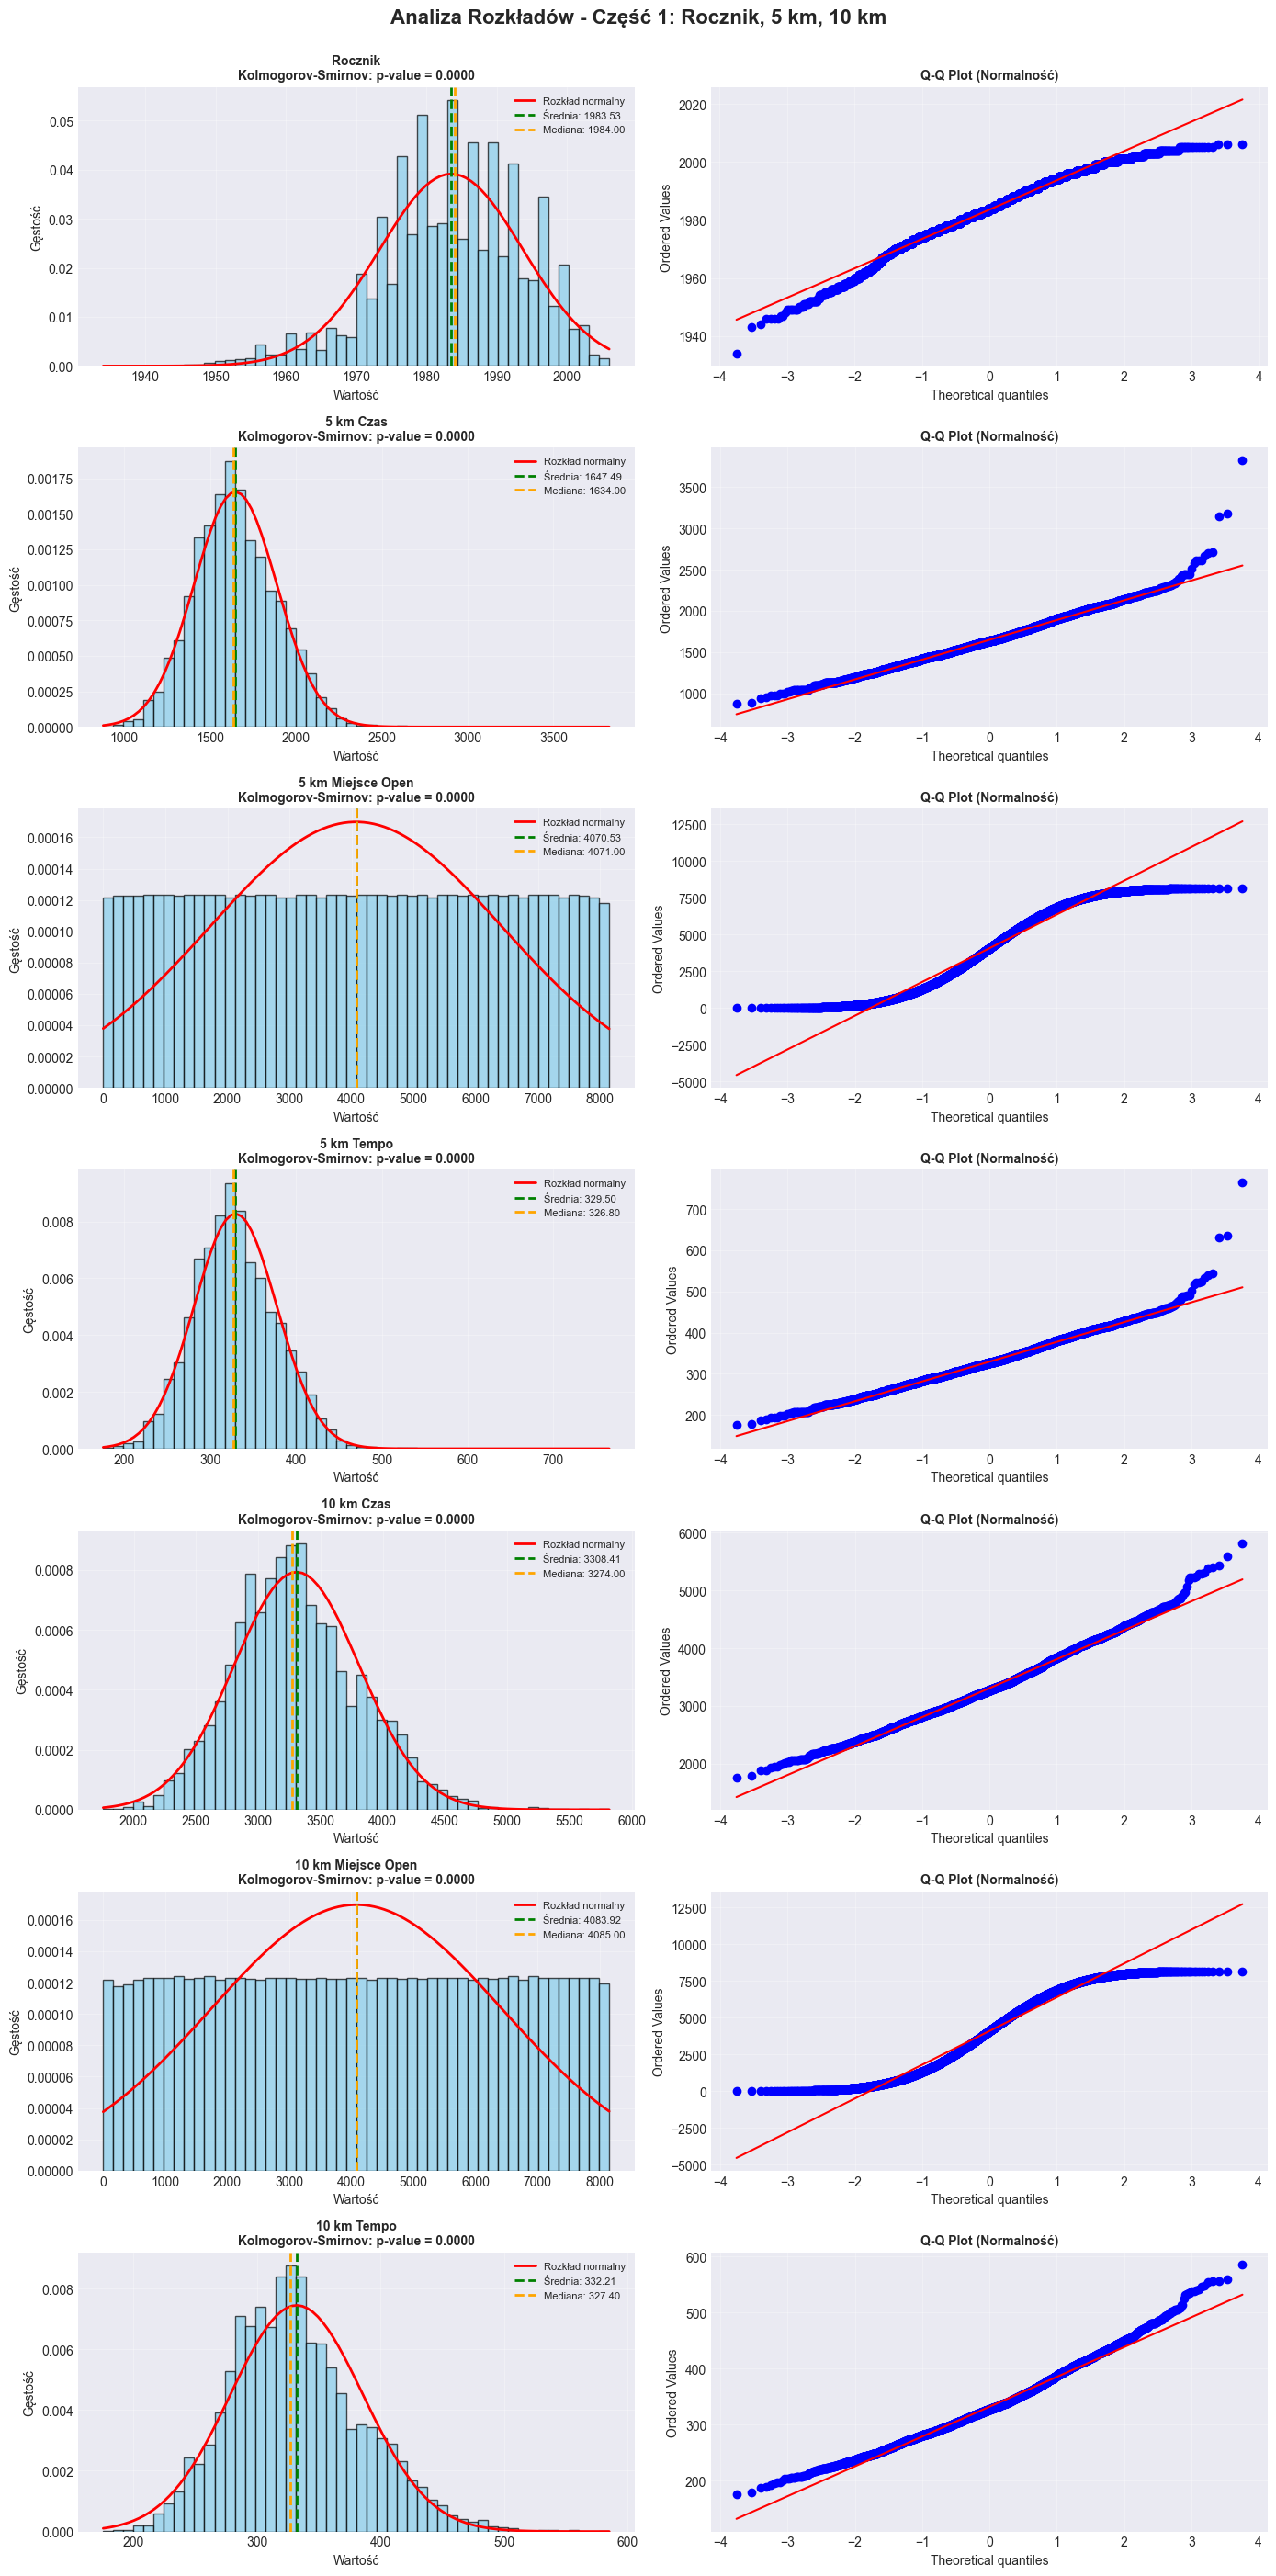


PODSUMOWANIE WYNIKÓW - CZĘŚĆ 1:

Rocznik:
  Średnia: 1983.53, Odch. std: 10.20, Mediana: 1984.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

5 km Czas:
  Średnia: 1647.49, Odch. std: 241.25, Mediana: 1634.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

5 km Miejsce Open:
  Średnia: 4070.53, Odch. std: 2349.02, Mediana: 4071.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

5 km Tempo:
  Średnia: 329.50, Odch. std: 48.25, Mediana: 326.80
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

10 km Czas:
  Średnia: 3308.41, Odch. std: 503.18, Mediana: 3274.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

10 km Miejsce Open:
  Średnia: 4083.92, Odch. std: 2350.55, Mediana: 4085.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

10 km Tempo:
  Średnia: 332.21, Odch. std: 53.57, Mediana: 327.40
  Test: Kolmogo

In [55]:
print("=" * 80)
print("ANALIZA ROZKŁADÓW - CZĘŚĆ 1:")
print("=" * 80)


part1_columns = ['Rocznik', '5 km Czas', '5 km Miejsce Open', '5 km Tempo', 
                 '10 km Czas', '10 km Miejsce Open', '10 km Tempo']
part1_columns = [col for col in part1_columns if col in df.columns]

n_cols = len(part1_columns)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))
fig.suptitle('Analiza Rozkładów - Część 1: Rocznik, 5 km, 10 km', fontsize=16, fontweight='bold', y=1.0)

results_part1 = []

if n_cols == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(part1_columns):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    result = analyze_distribution(df_with_outliers, col, ax1, ax2)
    if result:
        results_part1.append(result)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW - CZĘŚĆ 1:")
print("=" * 80)
for result in results_part1:
    print(f"\n{result['column']}:")
    print(f"  Średnia: {result['mean']:.2f}, Odch. std: {result['std']:.2f}, Mediana: {result['median']:.2f}")
    print(f"  Test: {result['test']}, p-value: {result['p_value']:.4f}")
    print(f"  {result['normality']}")


ANALIZA ROZKŁADÓW - CZĘŚĆ 2:


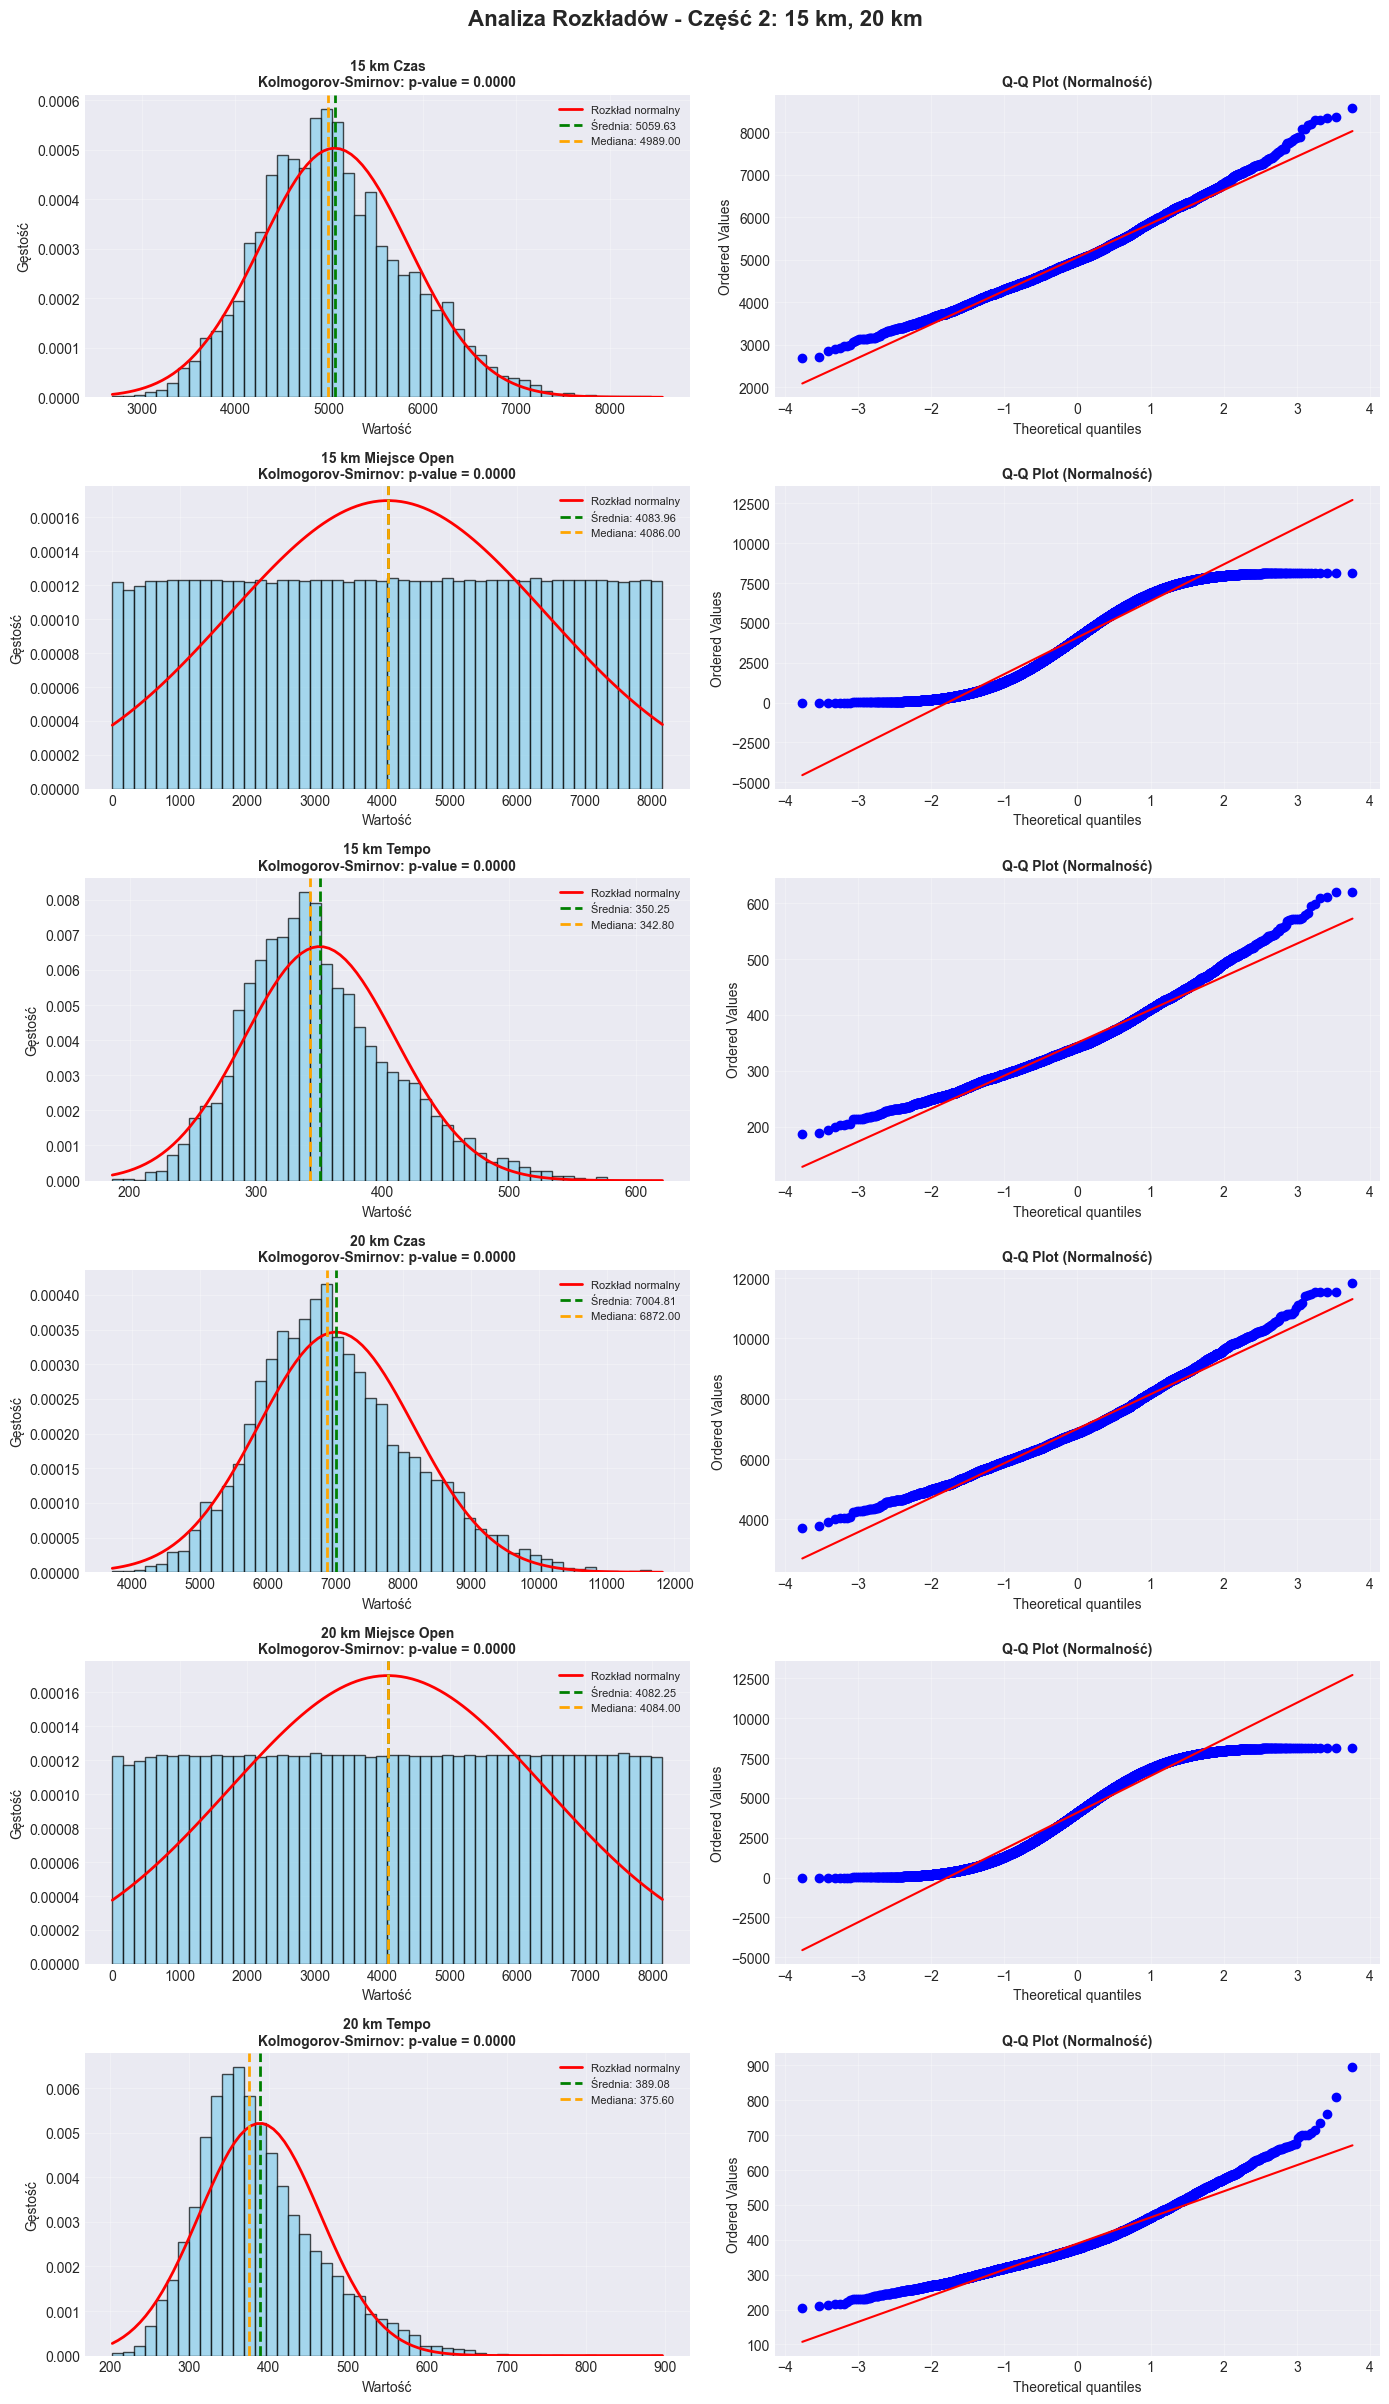


PODSUMOWANIE WYNIKÓW - CZĘŚĆ 2:

15 km Czas:
  Średnia: 5059.63, Odch. std: 793.05, Mediana: 4989.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

15 km Miejsce Open:
  Średnia: 4083.96, Odch. std: 2349.70, Mediana: 4086.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

15 km Tempo:
  Średnia: 350.25, Odch. std: 59.85, Mediana: 342.80
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

20 km Czas:
  Średnia: 7004.81, Odch. std: 1151.65, Mediana: 6872.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

20 km Miejsce Open:
  Średnia: 4082.25, Odch. std: 2348.76, Mediana: 4084.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

20 km Tempo:
  Średnia: 389.08, Odch. std: 76.51, Mediana: 375.60
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)


In [56]:
print("=" * 80)
print("ANALIZA ROZKŁADÓW - CZĘŚĆ 2:")
print("=" * 80)

part2_columns = ['15 km Czas', '15 km Miejsce Open', '15 km Tempo',
                 '20 km Czas', '20 km Miejsce Open', '20 km Tempo']
part2_columns = [col for col in part2_columns if col in df.columns]

n_cols = len(part2_columns)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))
fig.suptitle('Analiza Rozkładów - Część 2: 15 km, 20 km', fontsize=16, fontweight='bold', y=1.0)

results_part2 = []

if n_cols == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(part2_columns):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    result = analyze_distribution(df_with_outliers, col, ax1, ax2)
    if result:
        results_part2.append(result)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW - CZĘŚĆ 2:")
print("=" * 80)
for result in results_part2:
    print(f"\n{result['column']}:")
    print(f"  Średnia: {result['mean']:.2f}, Odch. std: {result['std']:.2f}, Mediana: {result['median']:.2f}")
    print(f"  Test: {result['test']}, p-value: {result['p_value']:.4f}")
    print(f"  {result['normality']}")


## Analiza przydatności kolumn "Miejsce Open" dla modelu ML



ANALIZA ROZKŁADÓW - CZĘŚĆ 3:


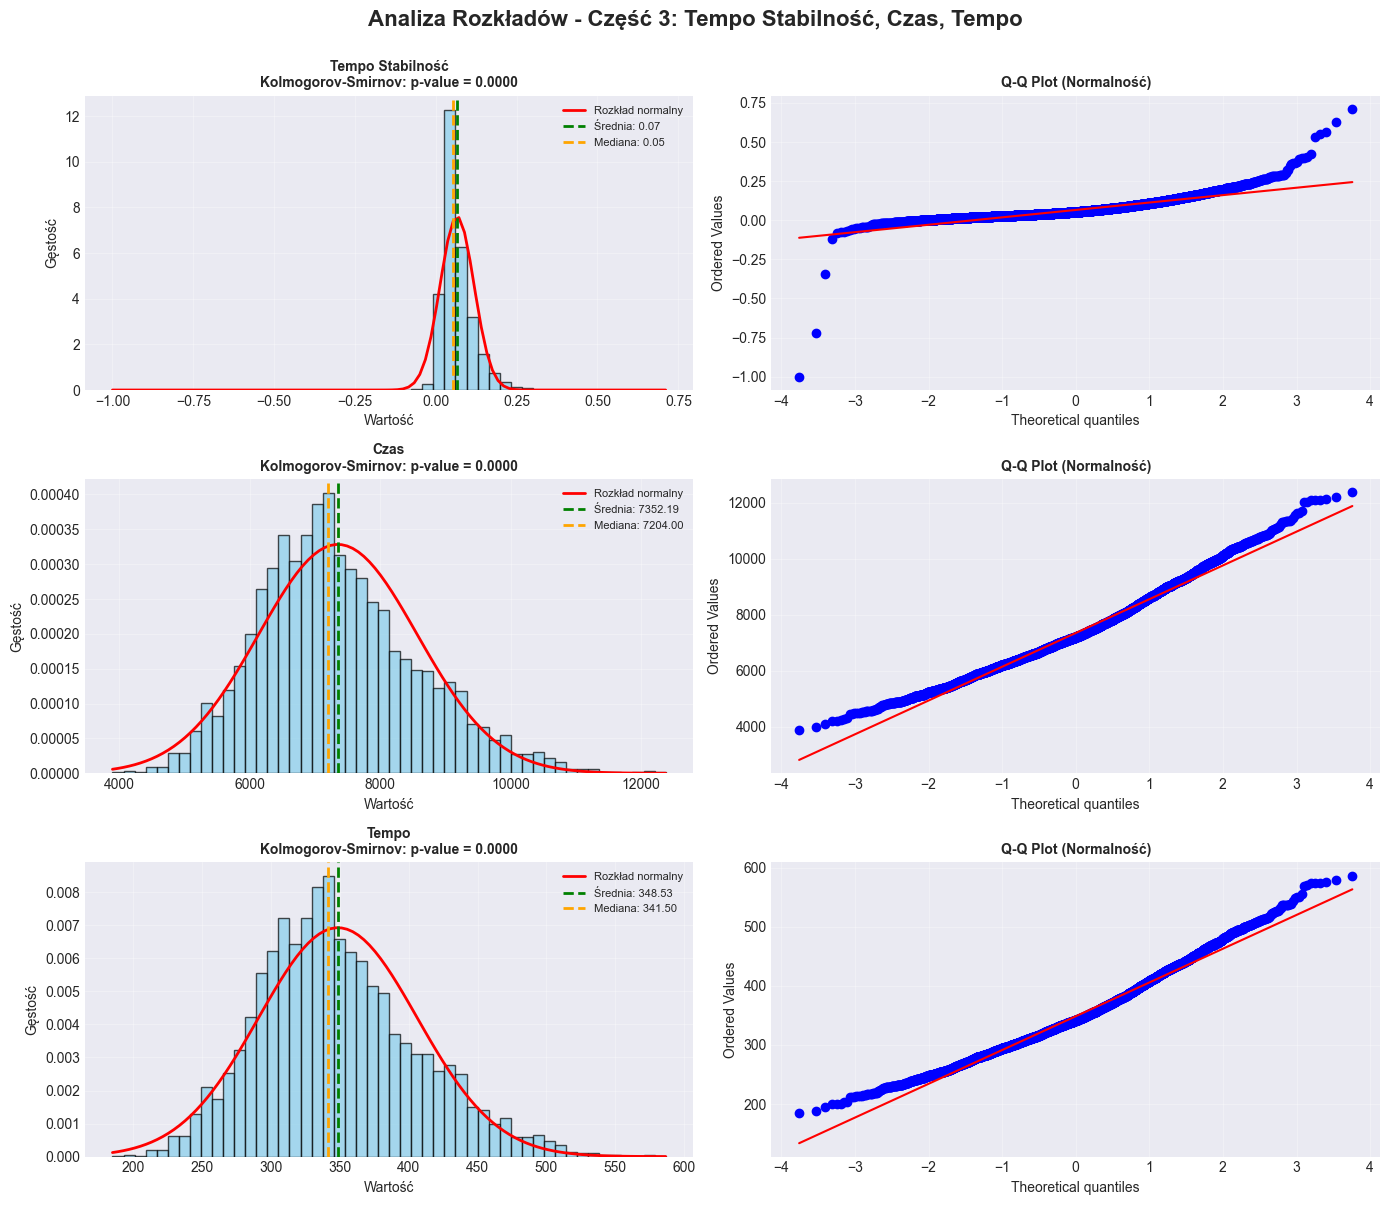


PODSUMOWANIE WYNIKÓW - CZĘŚĆ 3:

Tempo Stabilność:
  Średnia: 0.07, Odch. std: 0.05, Mediana: 0.05
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

Czas:
  Średnia: 7352.19, Odch. std: 1214.91, Mediana: 7204.00
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)

Tempo:
  Średnia: 348.53, Odch. std: 57.59, Mediana: 341.50
  Test: Kolmogorov-Smirnov, p-value: 0.0000
  ✗ Nie jest normalny (p ≤ 0.05)


In [57]:
print("=" * 80)
print("ANALIZA ROZKŁADÓW - CZĘŚĆ 3:")
print("=" * 80)

part3_columns = ['Tempo Stabilność', 'Czas', 'Tempo']
part3_columns = [col for col in part3_columns if col in df.columns]

n_cols = len(part3_columns)
fig, axes = plt.subplots(n_cols, 2, figsize=(14, 4 * n_cols))
fig.suptitle('Analiza Rozkładów - Część 3: Tempo Stabilność, Czas, Tempo', fontsize=16, fontweight='bold', y=1.0)

results_part3 = []

if n_cols == 1:
    axes = axes.reshape(1, -1)

for idx, col in enumerate(part3_columns):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    result = analyze_distribution(df_with_outliers, col, ax1, ax2)
    if result:
        results_part3.append(result)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("PODSUMOWANIE WYNIKÓW - CZĘŚĆ 3:")
print("=" * 80)
for result in results_part3:
    print(f"\n{result['column']}:")
    print(f"  Średnia: {result['mean']:.2f}, Odch. std: {result['std']:.2f}, Mediana: {result['median']:.2f}")
    print(f"  Test: {result['test']}, p-value: {result['p_value']:.4f}")
    print(f"  {result['normality']}")


In [58]:
# Zapis df_with_outliers do pliku CSV
# Ten DataFrame zawiera:
# - Wszystkie dane po interpolacjach
# - Tylko 200 brakujących wartości w kolumnie 'Rocznik'
# - ZAWIERA wartości odstające

print("ZAPIS DF_WITH_OUTLIERS DO PLIKU CSV:")
print("=" * 80)

print(f"\nLiczba rekordów: {len(df_with_outliers)}")
print(f"\nBrakujące wartości:")
print(df_with_outliers.isnull().sum())

output_filename = 'df_with_outliers_2023.csv'
df_with_outliers.to_csv(output_filename, sep=';', index=False)

print(f"\n✓ Zapisano do pliku: {output_filename}")
print(f"✓ Liczba rekordów: {len(df_with_outliers)}")
print(f"✓ Liczba kolumn: {len(df_with_outliers.columns)}")

ZAPIS DF_WITH_OUTLIERS DO PLIKU CSV:

Liczba rekordów: 8113

Brakujące wartości:
Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
dtype: int64

✓ Zapisano do pliku: df_with_outliers_2023.csv
✓ Liczba rekordów: 8113
✓ Liczba kolumn: 21


In [59]:
df_with_outliers.isnull().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
dtype: int64

## Analiza Boxplot - Wykrywanie wartości odstających

Boxploty pozwalają zidentyfikować wartości odstające (outliers) w danych. 

Dla każdej kolumny związanej z kilometrami (5, 10, 15, 20) oraz dla końcowych wartości sprawdzimy:
- **Miejsce Open** - pozycja zawodnika
- **Czas** - czas na danym kilometrze
- **Tempo** - tempo na danym kilometrze
- **Tempo Stabilność** - stabilność tempa
- **Czas** (końcowy) - całkowity czas
- **Tempo** (końcowe) - końcowe tempo

Wartości odstające to punkty poza "wąsami" boxplotu (zwykle > 1.5 * IQR od kwartyli).


ANALIZA BOXPLOT - WYKRYWANIE WARTOŚCI ODSTAJĄCYCH

✓ Znaleziono 15 kolumn do analizy


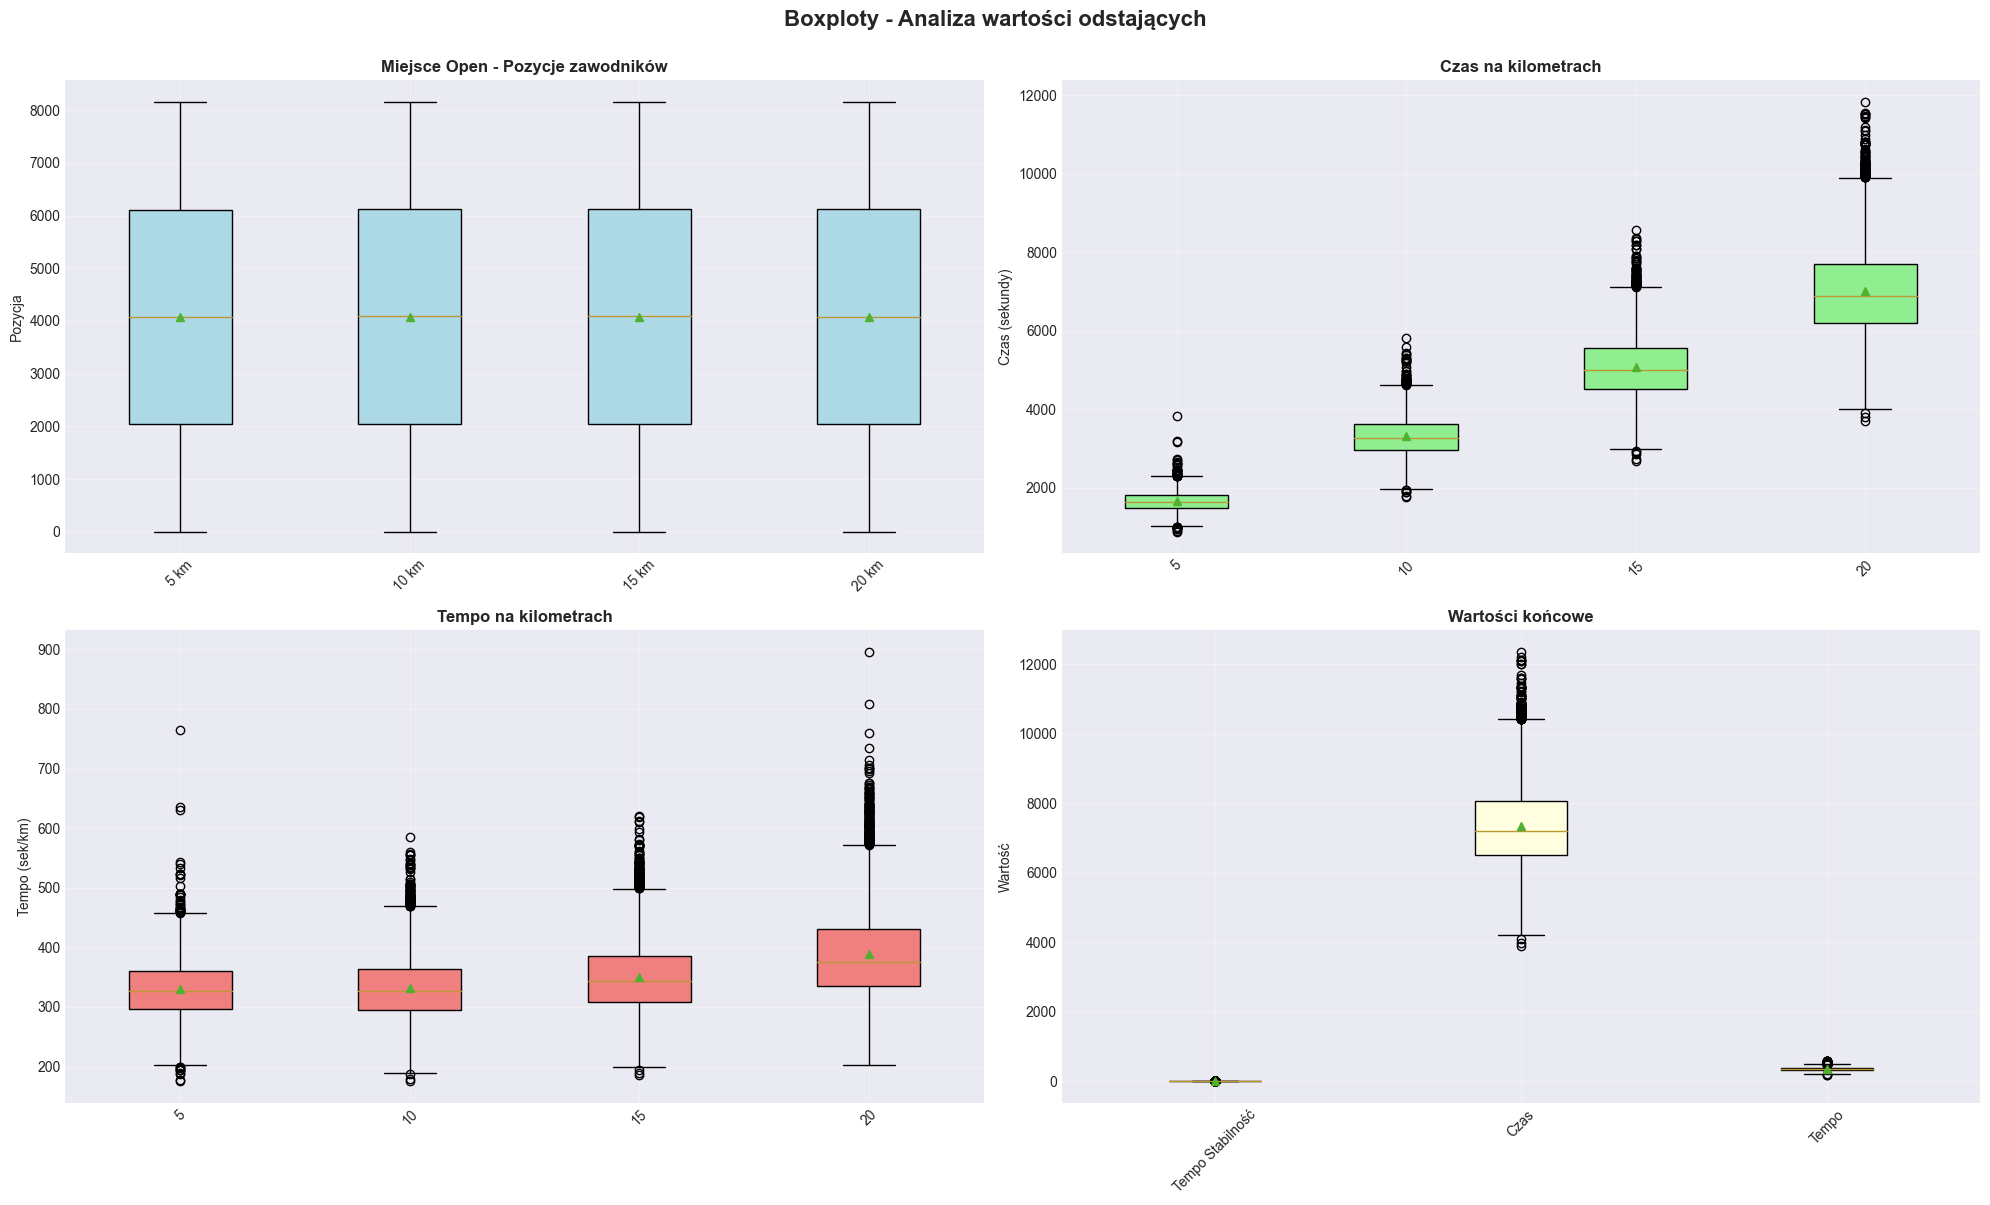


SZCZEGÓŁOWA ANALIZA WARTOŚCI ODSTAJĄCYCH:

            Column Total Outliers Outlier %      Q1  Median      Q3 Lower Bound Upper Bound     Min      Max
         5 km Czas  8113       47     0.58% 1481.00 1634.00 1805.00      995.00     2291.00  877.00  3825.00
 5 km Miejsce Open  8113        0     0.00% 2036.00 4071.00 6104.00    -4066.00    12206.00    1.00  8147.00
        5 km Tempo  8113       47     0.58%  296.20  326.80  361.00      199.00      458.20  175.40   765.00
        10 km Czas  8113       69     0.85% 2955.00 3274.00 3622.00     1954.50     4622.50 1755.00  5819.00
10 km Miejsce Open  8113        0     0.00% 2049.00 4085.00 6120.00    -4057.50    12226.50    1.00  8156.00
       10 km Tempo  8113      100     1.23%  294.40  327.40  364.40      189.40      469.40  175.60   585.20
        15 km Czas  8113       84     1.04% 4500.00 4989.00 5547.00     2929.50     7117.50 2687.00  8561.00
15 km Miejsce Open  8113        0     0.00% 2050.00 4086.00 6119.00    -4053.50    1

In [60]:
import numpy as np

print("ANALIZA BOXPLOT - WYKRYWANIE WARTOŚCI ODSTAJĄCYCH")
print("=" * 80)

kilometer_columns = {
    '5 km': ['5 km Czas', '5 km Miejsce Open', '5 km Tempo'],
    '10 km': ['10 km Czas', '10 km Miejsce Open', '10 km Tempo'],
    '15 km': ['15 km Czas', '15 km Miejsce Open', '15 km Tempo'],
    '20 km': ['20 km Czas', '20 km Miejsce Open', '20 km Tempo']
}

final_columns = ['Tempo Stabilność', 'Czas', 'Tempo']

all_columns_to_plot = []
for km, cols in kilometer_columns.items():
    for col in cols:
        if col in df.columns:
            all_columns_to_plot.append(col)

for col in final_columns:
    if col in df.columns:
        all_columns_to_plot.append(col)

print(f"\n✓ Znaleziono {len(all_columns_to_plot)} kolumn do analizy")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Boxploty - Analiza wartości odstających', fontsize=16, fontweight='bold', y=1.0)

ax1 = axes[0, 0]
miejsce_cols = [col for col in all_columns_to_plot if 'Miejsce Open' in col]
if miejsce_cols:
    data_miejsce = [df_with_outliers[col].dropna() for col in miejsce_cols]
    bp1 = ax1.boxplot(data_miejsce, labels=[col.replace(' Miejsce Open', '') for col in miejsce_cols], 
                       patch_artist=True, showmeans=True)
    ax1.set_title('Miejsce Open - Pozycje zawodników', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Pozycja')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')
else:
    ax1.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax1.transAxes)


ax2 = axes[0, 1]
czas_cols = [col for col in all_columns_to_plot if 'km Czas' in col]
if czas_cols:
    data_czas = [df_with_outliers[col].dropna() for col in czas_cols]
    bp2 = ax2.boxplot(data_czas, labels=[col.replace(' km Czas', '') for col in czas_cols],
                      patch_artist=True, showmeans=True)
    ax2.set_title('Czas na kilometrach', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Czas (sekundy)')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    for patch in bp2['boxes']:
        patch.set_facecolor('lightgreen')
else:
    ax2.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax2.transAxes)


ax3 = axes[1, 0]
tempo_cols = [col for col in all_columns_to_plot if 'km Tempo' in col]
if tempo_cols:
    data_tempo = [df_with_outliers[col].dropna() for col in tempo_cols]
    bp3 = ax3.boxplot(data_tempo, labels=[col.replace(' km Tempo', '') for col in tempo_cols],
                      patch_artist=True, showmeans=True)
    ax3.set_title('Tempo na kilometrach', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Tempo (sek/km)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    for patch in bp3['boxes']:
        patch.set_facecolor('lightcoral')
else:
    ax3.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax3.transAxes)


ax4 = axes[1, 1]
final_cols = [col for col in final_columns if col in all_columns_to_plot]
if final_cols:
    data_final = [df_with_outliers[col].dropna() for col in final_cols]
    bp4 = ax4.boxplot(data_final, labels=final_cols, patch_artist=True, showmeans=True)
    ax4.set_title('Wartości końcowe', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Wartość')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    for patch in bp4['boxes']:
        patch.set_facecolor('lightyellow')
else:
    ax4.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


print("\n" + "=" * 80)
print("SZCZEGÓŁOWA ANALIZA WARTOŚCI ODSTAJĄCYCH:")
print("=" * 80)

def detect_outliers_iqr(data, column_name):
    """Wykrywa wartości odstające używając metody IQR"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers, lower_bound, upper_bound, Q1, Q3

outlier_summary = []

for col in all_columns_to_plot:
    data = df_with_outliers[col].dropna()
    if len(data) > 0:
        outliers, lower, upper, Q1, Q3 = detect_outliers_iqr(data, col)
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(data)) * 100 if len(data) > 0 else 0
        
        outlier_summary.append({
            'Column': col,
            'Total': str(len(data)),
            'Outliers': str(outlier_count),
            'Outlier %': f"{outlier_pct:.2f}%",
            'Q1': f"{Q1:.2f}",
            'Median': f"{data.median():.2f}",
            'Q3': f"{Q3:.2f}",
            'Lower Bound': f"{lower:.2f}",
            'Upper Bound': f"{upper:.2f}",
            'Min': f"{data.min():.2f}",
            'Max': f"{data.max():.2f}"
        })


if outlier_summary:
    summary_df = pd.DataFrame(outlier_summary)
    print("\n" + summary_df.to_string(index=False))
    
    
    print("\n" + "=" * 80)
    print("PODSUMOWANIE:")
    print("=" * 80)
    
    total_outliers = sum(int(row['Outliers']) for row in outlier_summary if row['Outliers'].isdigit())
    total_records = sum(int(row['Total']) for row in outlier_summary if row['Total'].isdigit())
    
    print(f"\n✓ Przeanalizowano: {len(outlier_summary)} kolumn")
    print(f"✓ Łączna liczba rekordów: {total_records}")
    print(f"✓ Łączna liczba wartości odstających: {total_outliers}")
    print(f"✓ Procent wartości odstających: {(total_outliers/total_records)*100:.2f}%")
    
    
    print("\n📊 Kolumny z największą liczbą wartości odstających:")
    sorted_summary = sorted(outlier_summary, key=lambda x: int(x['Outliers']) if x['Outliers'].isdigit() else 0, reverse=True)
    for idx, row in enumerate(sorted_summary[:5], 1):
        print(f"  {idx}. {row['Column']:30s}: {row['Outliers']} outliers ({row['Outlier %']})")
else:
    print("\n⚠ Nie znaleziono kolumn do analizy")


### 1418/8950 - 15.8%

In [61]:
df_with_outliers['Wiek'] = 2023 - df['Rocznik']
df_with_outliers

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek
0,1.0,M,1.0,M30,1.0,1992.0,877,1.0,175.4,1755.0,1.0,175.6,2687,1.0,186.4,3703.0,1.0,203.2,0.031400,3899.0,184.830529,31.0
1,2.0,M,2.0,M30,2.0,1986.0,888,2.0,177.6,1783.0,2.0,179.0,2726,2.0,188.6,3788.0,2.0,212.4,0.038000,3983.0,188.812515,37.0
2,3.0,M,3.0,M20,1.0,1996.0,946,4.0,189.2,1883.0,3.0,187.4,2854,3.0,194.2,3909.0,3.0,211.0,0.024067,4104.0,194.548471,27.0
3,4.0,M,4.0,M30,3.0,1988.0,971,6.0,194.2,1930.0,5.0,191.8,2929,5.0,199.8,4014.0,4.0,217.0,0.025467,4216.0,199.857786,35.0
4,5.0,M,5.0,M20,2.0,1995.0,972,7.0,194.4,1955.0,7.0,196.6,2971,7.0,203.2,4047.0,5.0,215.2,0.023000,4227.0,200.379237,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8145,8146.0,K,2318.0,K40,806.0,1976.0,2512,8136.0,502.4,5245.0,8147.0,546.6,8343,8150.0,619.6,11540.0,8147.0,639.4,0.161333,12108.0,573.974876,47.0
8146,8147.0,K,2319.0,K70,5.0,1952.0,2718,8143.0,543.6,5428.0,8154.0,542.0,8287,8148.0,571.8,11529.0,8146.0,648.4,0.114733,12116.0,574.354112,71.0
8147,8148.0,M,5829.0,M70,39.0,1952.0,2447,8132.0,489.4,5186.0,8143.0,547.8,8182,8146.0,599.2,11529.0,8145.0,669.4,0.197133,12142.0,575.586632,71.0
8148,8149.0,K,2320.0,K30,842.0,1985.0,2309,8114.0,461.8,4974.0,8141.0,533.0,7842,8139.0,573.6,11411.0,8141.0,713.8,0.265533,12211.0,578.857549,38.0


In [62]:
df_with_outliers.head()


,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek
0,1.0,M,1.0,M30,1.0,1992.0,877,1.0,175.4,1755.0,1.0,175.6,2687,1.0,186.4,3703.0,1.0,203.2,0.031400,3899.0,184.830529,31.0
1,2.0,M,2.0,M30,2.0,1986.0,888,2.0,177.6,1783.0,2.0,179.0,2726,2.0,188.6,3788.0,2.0,212.4,0.038000,3983.0,188.812515,37.0
2,3.0,M,3.0,M20,1.0,1996.0,946,4.0,189.2,1883.0,3.0,187.4,2854,3.0,194.2,3909.0,3.0,211.0,0.024067,4104.0,194.548471,27.0
3,4.0,M,4.0,M30,3.0,1988.0,971,6.0,194.2,1930.0,5.0,191.8,2929,5.0,199.8,4014.0,4.0,217.0,0.025467,4216.0,199.857786,35.0
4,5.0,M,5.0,M20,2.0,1995.0,972,7.0,194.4,1955.0,7.0,196.6,2971,7.0,203.2,4047.0,5.0,215.2,0.023000,4227.0,200.379237,28.0


In [63]:
df_with_outliers.isna().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
Wiek                         200
dtype: int64

In [64]:
df_with_outliers['Płeć'].value_counts()

Płeć
M    5799
K    2314
Name: count, dtype: int64

#### Mamy doczynienia z niezbalansowanymi danymi ponad 2.5 razy wiecej panów

In [65]:
# !conda install -y conda-forge::pandera
import pandera as pa

In [66]:
##!pip install --quiet black pyyaml frictionless

In [67]:
import numpy as np
from sklearn.impute import KNNImputer

df_with_outliers['Rocznik'] = pd.to_numeric(df_with_outliers['Rocznik'], errors='coerce')
df_with_outliers['5 km Czas'] = pd.to_numeric(df_with_outliers['5 km Czas'], errors='coerce')
df_with_outliers['Czas'] = pd.to_numeric(df_with_outliers['Czas'], errors='coerce')

def uzupelnij_tylko_brakujacy_wiek(group):
    
    if group['Wiek'].isna().sum() == 0:
        return group
    
   
    if len(group) < 5:
        group['Wiek'] = group['Wiek'].fillna(group['Wiek'].median())
        return group

    
    imputer = KNNImputer(n_neighbors=5, weights='distance')
    dane_wejsciowe = group[['5 km Czas', 'Wiek']].values
    
    dane_uzupelnione = imputer.fit_transform(dane_wejsciowe)
    
    
    group['Wiek'] = dane_uzupelnione[:, 1]
    
    return group

df_with_outliers = df_with_outliers.groupby('Kategoria wiekowa', group_keys=False).apply(uzupelnij_tylko_brakujacy_wiek)

df_with_outliers['Wiek'] = df_with_outliers['Wiek'].round()

In [68]:
df_with_outliers.isna().sum()

Miejsce                        0
Płeć                           0
Płeć Miejsce                   0
Kategoria wiekowa              0
Kategoria wiekowa Miejsce      0
Rocznik                      200
5 km Czas                      0
5 km Miejsce Open              0
5 km Tempo                     0
10 km Czas                     0
10 km Miejsce Open             0
10 km Tempo                    0
15 km Czas                     0
15 km Miejsce Open             0
15 km Tempo                    0
20 km Czas                     0
20 km Miejsce Open             0
20 km Tempo                    0
Tempo Stabilność               0
Czas                           0
Tempo                          0
Wiek                           0
dtype: int64

In [69]:
df_with_outliers.tail()

,Miejsce,Płeć,Płeć Miejsce,Kategoria wiekowa,Kategoria wiekowa Miejsce,Rocznik,5 km Czas,5 km Miejsce Open,5 km Tempo,10 km Czas,10 km Miejsce Open,10 km Tempo,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek
8145,8146.0,K,2318.0,K40,806.0,1976.0,2512,8136.0,502.4,5245.0,8147.0,546.6,8343,8150.0,619.6,11540.0,8147.0,639.4,0.161333,12108.0,573.974876,47.0
8146,8147.0,K,2319.0,K70,5.0,1952.0,2718,8143.0,543.6,5428.0,8154.0,542.0,8287,8148.0,571.8,11529.0,8146.0,648.4,0.114733,12116.0,574.354112,71.0
8147,8148.0,M,5829.0,M70,39.0,1952.0,2447,8132.0,489.4,5186.0,8143.0,547.8,8182,8146.0,599.2,11529.0,8145.0,669.4,0.197133,12142.0,575.586632,71.0
8148,8149.0,K,2320.0,K30,842.0,1985.0,2309,8114.0,461.8,4974.0,8141.0,533.0,7842,8139.0,573.6,11411.0,8141.0,713.8,0.265533,12211.0,578.857549,38.0
8149,8150.0,K,2321.0,K60,34.0,1955.0,2663,8141.0,532.6,5589.0,8155.0,585.2,8561,8153.0,594.4,11825.0,8148.0,652.8,0.123267,12373.0,586.537094,68.0


In [70]:
df_with_outliers = df_with_outliers.drop(columns=['Rocznik'])
print("Kolumna 'Rocznik' została usunięta.")
print(f"\nAktualne kolumny: {df_with_outliers.columns.tolist()}")

Kolumna 'Rocznik' została usunięta.

Aktualne kolumny: ['Miejsce', 'Płeć', 'Płeć Miejsce', 'Kategoria wiekowa', 'Kategoria wiekowa Miejsce', '5 km Czas', '5 km Miejsce Open', '5 km Tempo', '10 km Czas', '10 km Miejsce Open', '10 km Tempo', '15 km Czas', '15 km Miejsce Open', '15 km Tempo', '20 km Czas', '20 km Miejsce Open', '20 km Tempo', 'Tempo Stabilność', 'Czas', 'Tempo', 'Wiek']


In [71]:
from pandera import DataFrameSchema, Column, Check, Index, MultiIndex

schema = DataFrameSchema(
    columns={
        "Miejsce": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=9000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=True,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce końcowe zawodnika w biegu",
            title="Miejsce",
        ),
        "Płeć": Column(
            dtype="object",
            checks=[
                Check.isin(["K", "M"]), 
            ],
            nullable=False,
            unique=False,
            coerce=False,
            required=True,
            regex=False,
            description="Płeć zawodnika: K - kobieta, M - mężczyzna",
            title="Płeć",
        ),
        "Płeć Miejsce": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=9000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce w klasyfikacji płci",
            title="Płeć Miejsce",
        ),
        "Kategoria wiekowa": Column(
            dtype="object",
            checks=[
                # Wzorzec: K lub M + liczba (np. K20, M30, K40, M50, K60, M70)
                Check.str_matches(r"^[KM]\d{2}$"),
            ],
            nullable=False,
            unique=False,
            coerce=False,
            required=True,
            regex=False,
            description="Kategoria wiekowa zawodnika (np. K30, M40)",
            title="Kategoria wiekowa",
        ),
        "Kategoria wiekowa Miejsce": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=3000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce w kategorii wiekowej",
            title="Kategoria wiekowa Miejsce",
        ),
        "5 km Czas": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=600, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=6000, raise_warning=False, ignore_na=True  
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Czas na 5 km w sekundach",
            title="5 km Czas",
        ),
        "5 km Miejsce Open": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=9000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce open na 5 km",
            title="5 km Miejsce Open",
        ),
        "5 km Tempo": Column(
            dtype="float64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=120.0, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=1200.0, raise_warning=False, ignore_na=True  
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Tempo na 5 km w sekundach na kilometr",
            title="5 km Tempo",
        ),
        "10 km Czas": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1200, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=12000, raise_warning=False, ignore_na=True 
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Czas na 10 km w sekundach",
            title="10 km Czas",
        ),
        "10 km Miejsce Open": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=9000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce open na 10 km",
            title="10 km Miejsce Open",
        ),
        "10 km Tempo": Column(
            dtype="float64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=120.0, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=1200.0, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Tempo na 10 km w sekundach na kilometr",
            title="10 km Tempo",
        ),
        "15 km Czas": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1800, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=18000, raise_warning=False, ignore_na=True  
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Czas na 15 km w sekundach",
            title="15 km Czas",
        ),
        "15 km Miejsce Open": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=9000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce open na 15 km",
            title="15 km Miejsce Open",
        ),
        "15 km Tempo": Column(
            dtype="float64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=120.0, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=1200.0, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Tempo na 15 km w sekundach na kilometr",
            title="15 km Tempo",
        ),
        "20 km Czas": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=2400, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=24000, raise_warning=False, ignore_na=True 
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Czas na 20 km w sekundach",
            title="20 km Czas",
        ),
        "20 km Miejsce Open": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=1, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=15000, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Miejsce open na 20 km",
            title="20 km Miejsce Open",
        ),
        "20 km Tempo": Column(
            dtype="float64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=120.0, raise_warning=False, ignore_na=True
                ),
                Check.less_than_or_equal_to(
                    max_value=1200.0, raise_warning=False, ignore_na=True
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Tempo na 20 km w sekundach na kilometr",
            title="20 km Tempo",
        ),
        "Tempo Stabilność": Column(
            dtype="float64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=-1.0, raise_warning=False, ignore_na=True 
                ),
                Check.less_than_or_equal_to(
                    max_value=1.0, raise_warning=False, ignore_na=True  
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Stabilność tempa (-1 do 1, gdzie 0 = idealne tempo)",
            title="Tempo Stabilność",
        ),
        "Czas": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=2520, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=25200, raise_warning=False, ignore_na=True  
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Całkowity czas biegu w sekundach",
            title="Czas",
        ),
        "Tempo": Column(
            dtype="float64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=120.0, raise_warning=False, ignore_na=True 
                ),
                Check.less_than_or_equal_to(
                    max_value=1200.0, raise_warning=False, ignore_na=True 
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Średnie tempo biegu w sekundach na kilometr",
            title="Tempo",
        ),
        "Wiek": Column(
            dtype="int64",
            checks=[
                Check.greater_than_or_equal_to(
                    min_value=16, raise_warning=False, ignore_na=True  
                ),
                Check.less_than_or_equal_to(
                    max_value=100, raise_warning=False, ignore_na=True  
                ),
            ],
            nullable=False,
            unique=False,
            coerce=True,
            required=True,
            regex=False,
            description="Wiek zawodnika w latach",
            title="Wiek",
        ),
    },
    checks=[
        # Sprawdzenie logicznej kolejności czasów - każdy kolejny dystans powinien mieć większy lub równy czas
        Check(
            lambda df: df["5 km Czas"].le(df["10 km Czas"]).all() 
                if "5 km Czas" in df.columns and "10 km Czas" in df.columns 
                else True,
            name="5km_przed_10km",
            error="Czas 5 km musi być mniejszy lub równy czasowi 10 km"
        ),
        Check(
            lambda df: df["10 km Czas"].le(df["15 km Czas"]).all() 
                if "10 km Czas" in df.columns and "15 km Czas" in df.columns 
                else True,
            name="10km_przed_15km",
            error="Czas 10 km musi być mniejszy lub równy czasowi 15 km"
        ),
        Check(
            lambda df: df["15 km Czas"].le(df["20 km Czas"]).all() 
                if "15 km Czas" in df.columns and "20 km Czas" in df.columns 
                else True,
            name="15km_przed_20km",
            error="Czas 15 km musi być mniejszy lub równy czasowi 20 km"
        ),
        Check(
            lambda df: df["20 km Czas"].le(df["Czas"]).all() 
                if "20 km Czas" in df.columns and "Czas" in df.columns 
                else True,
            name="20km_przed_mety",
            error="Czas 20 km musi być mniejszy lub równy czasowi końcowemu"
        ),
        Check(
            lambda df: df["Kategoria wiekowa"].str[0].eq(df["Płeć"]).all() 
                if "Kategoria wiekowa" in df.columns and "Płeć" in df.columns 
                else True,
            name="plec_kategoria_spojnosc",
            error="Pierwsza litera kategorii wiekowej musi odpowiadać płci"
        ),
        Check(
            lambda df: df["Płeć Miejsce"].le(df["Miejsce"]).all() 
                if "Płeć Miejsce" in df.columns and "Miejsce" in df.columns 
                else True,
            name="plec_miejsce_logika",
            error="Miejsce w klasyfikacji płci musi być <= miejsca ogólnego"
        ),
        Check(
            lambda df: df["Kategoria wiekowa Miejsce"].le(df["Płeć Miejsce"]).all() 
                if "Kategoria wiekowa Miejsce" in df.columns and "Płeć Miejsce" in df.columns 
                else True,
            name="kategoria_miejsce_logika",
            error="Miejsce w kategorii wiekowej musi być <= miejsca w płci"
        ),
    ],
    index=Index(
        dtype="int64",
        checks=[
            Check.greater_than_or_equal_to(
                min_value=0, raise_warning=False, ignore_na=True
            ),
        ],
        nullable=False,
        coerce=True,
        name=None,
        description="Indeks DataFrame",
        title=None,
    ),
    dtype=None,
    coerce=True,
    strict=False,
    name="HalfMarathonSchema",
    ordered=False,
    unique=None,
    report_duplicates="all",
    unique_column_names=True,
    add_missing_columns=False,
    title="Schemat danych półmaratonu",
    description="Schemat walidacji danych z półmaratonu wrocławskiego",
)

c:\Users\Admin\miniconda3\envs\zad9_domowe\Lib\site-packages\pandera\_pandas_deprecated.py:146: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


In [72]:
import pandera as pa
import importlib
import sys

if 'corrected_schema' in sys.modules:
    del sys.modules['corrected_schema']
import corrected_schema as cs_module
importlib.reload(cs_module)
corrected_schema = cs_module.schema

print("WALIDACJA DANYCH Z POPRAWIONYM SCHEMATEM")
print("=" * 80)
print(f"Używany schemat: {corrected_schema.name}")
print(f"Liczba kolumn w schemacie: {len(corrected_schema.columns)}")

try:
    validated_df = corrected_schema.validate(df_with_outliers)  
    print("\n✓ WALIDACJA ZAKOŃCZONA SUKCESEM!")
    print("=" * 80)
    print(f"\nKształt zwalidowanego DataFrame: {validated_df.shape}")
    print(f"\nTypy danych po walidacji:")
    print(validated_df.dtypes)
    print("\n✓ Wszystkie dane są zgodne ze schematem")
    
except pa.errors.SchemaError as e:
    print("\n✗ WALIDACJA NIE POWIODŁA SIĘ")
    print("=" * 80)
    print(f"\nBłąd: {e}")
    
except pa.errors.SchemaErrors as e:
    print("\n✗ WALIDACJA NIE POWIODŁA SIĘ - Znaleziono błędy schematu")
    print("=" * 80)
    
    failure_df = e.failure_cases
    print(f"\nŁączna liczba błędów: {len(failure_df)}")
    print(f"\n{'='*80}")
    print("SZCZEGÓŁY BŁĘDÓW:")
    print("=" * 80)
    
    with pd.option_context('display.max_rows', 50, 'display.max_columns', None, 'display.width', None, 'display.max_colwidth', 50):
        print(failure_df)
    
    print(f"\n{'='*80}")
    print("PODSUMOWANIE WEDŁUG KOLUMN:")
    print("=" * 80)
    if 'column' in failure_df.columns:
        print(failure_df['column'].value_counts())
    
    print(f"\n{'='*80}")
    print("PODSUMOWANIE WEDŁUG TYPU BŁĘDU:")
    print("=" * 80)
    if 'check' in failure_df.columns:
        print(failure_df['check'].value_counts())
    
    
    print("\n" + "="*80)
    print("NOTE: If errors are about 'Rocznik' with NaN values - this is acceptable!")
    print("Records with missing 'Rocznik' have 'Kategoria wiekowa' which is sufficient.")
    print("="*80)

WALIDACJA DANYCH Z POPRAWIONYM SCHEMATEM
Używany schemat: HalfMarathonSchema
Liczba kolumn w schemacie: 21

✓ WALIDACJA ZAKOŃCZONA SUKCESEM!

Kształt zwalidowanego DataFrame: (8113, 21)

Typy danych po walidacji:
Miejsce                        int64
Płeć                          object
Płeć Miejsce                   int64
Kategoria wiekowa             object
Kategoria wiekowa Miejsce      int64
5 km Czas                      int64
5 km Miejsce Open              int64
5 km Tempo                   float64
10 km Czas                     int64
10 km Miejsce Open             int64
10 km Tempo                  float64
15 km Czas                     int64
15 km Miejsce Open             int64
15 km Tempo                  float64
20 km Czas                     int64
20 km Miejsce Open             int64
20 km Tempo                  float64
Tempo Stabilność             float64
Czas                           int64
Tempo                        float64
Wiek                           int64
dtype: obj

In [73]:
df_with_outliers.isnull().sum()

Miejsce                      0
Płeć                         0
Płeć Miejsce                 0
Kategoria wiekowa            0
Kategoria wiekowa Miejsce    0
5 km Czas                    0
5 km Miejsce Open            0
5 km Tempo                   0
10 km Czas                   0
10 km Miejsce Open           0
10 km Tempo                  0
15 km Czas                   0
15 km Miejsce Open           0
15 km Tempo                  0
20 km Czas                   0
20 km Miejsce Open           0
20 km Tempo                  0
Tempo Stabilność             0
Czas                         0
Tempo                        0
Wiek                         0
dtype: int64

In [75]:
## !pip install pycaret

In [85]:
df_without_outliers = df_with_outliers.copy()

##### Następną komórkę z kodem trzeba odpalać do momentu ilości rekordów 9214 wtedy boxploty pokazują 0 wszędzie

In [98]:
print(f"Początkowa liczba rekordów: {len(df_without_outliers)}")

kolumny_do_sprawdzenia = ["Czas", "5 km Czas", "5 km Tempo","10 km Czas","10 km Tempo","15 km Czas",
"15 km Tempo","20 km Czas","20 km Tempo","Tempo Stabilność","Tempo"]

Q1 = df_without_outliers[kolumny_do_sprawdzenia].quantile(0.25)
Q3 = df_without_outliers[kolumny_do_sprawdzenia].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_mask = (df_without_outliers[kolumny_do_sprawdzenia] < lower_bound) | (df_without_outliers[kolumny_do_sprawdzenia] > upper_bound)
df_without_outliers = df_without_outliers[~outliers_mask.any(axis=1)]
print(f"Po usunięciu outlierów: {len(df_without_outliers)} rekordów")
print(f"Usunięto: {len(df_with_outliers) - len(df_without_outliers)} outlierów")

Początkowa liczba rekordów: 7233
Po usunięciu outlierów: 7233 rekordów
Usunięto: 880 outlierów


ANALIZA BOXPLOT - WERYFIKACJA PO USUNIĘCIU OUTLIERÓW

✓ Znaleziono 15 kolumn do weryfikacji w wyczyszczonym zbiorze


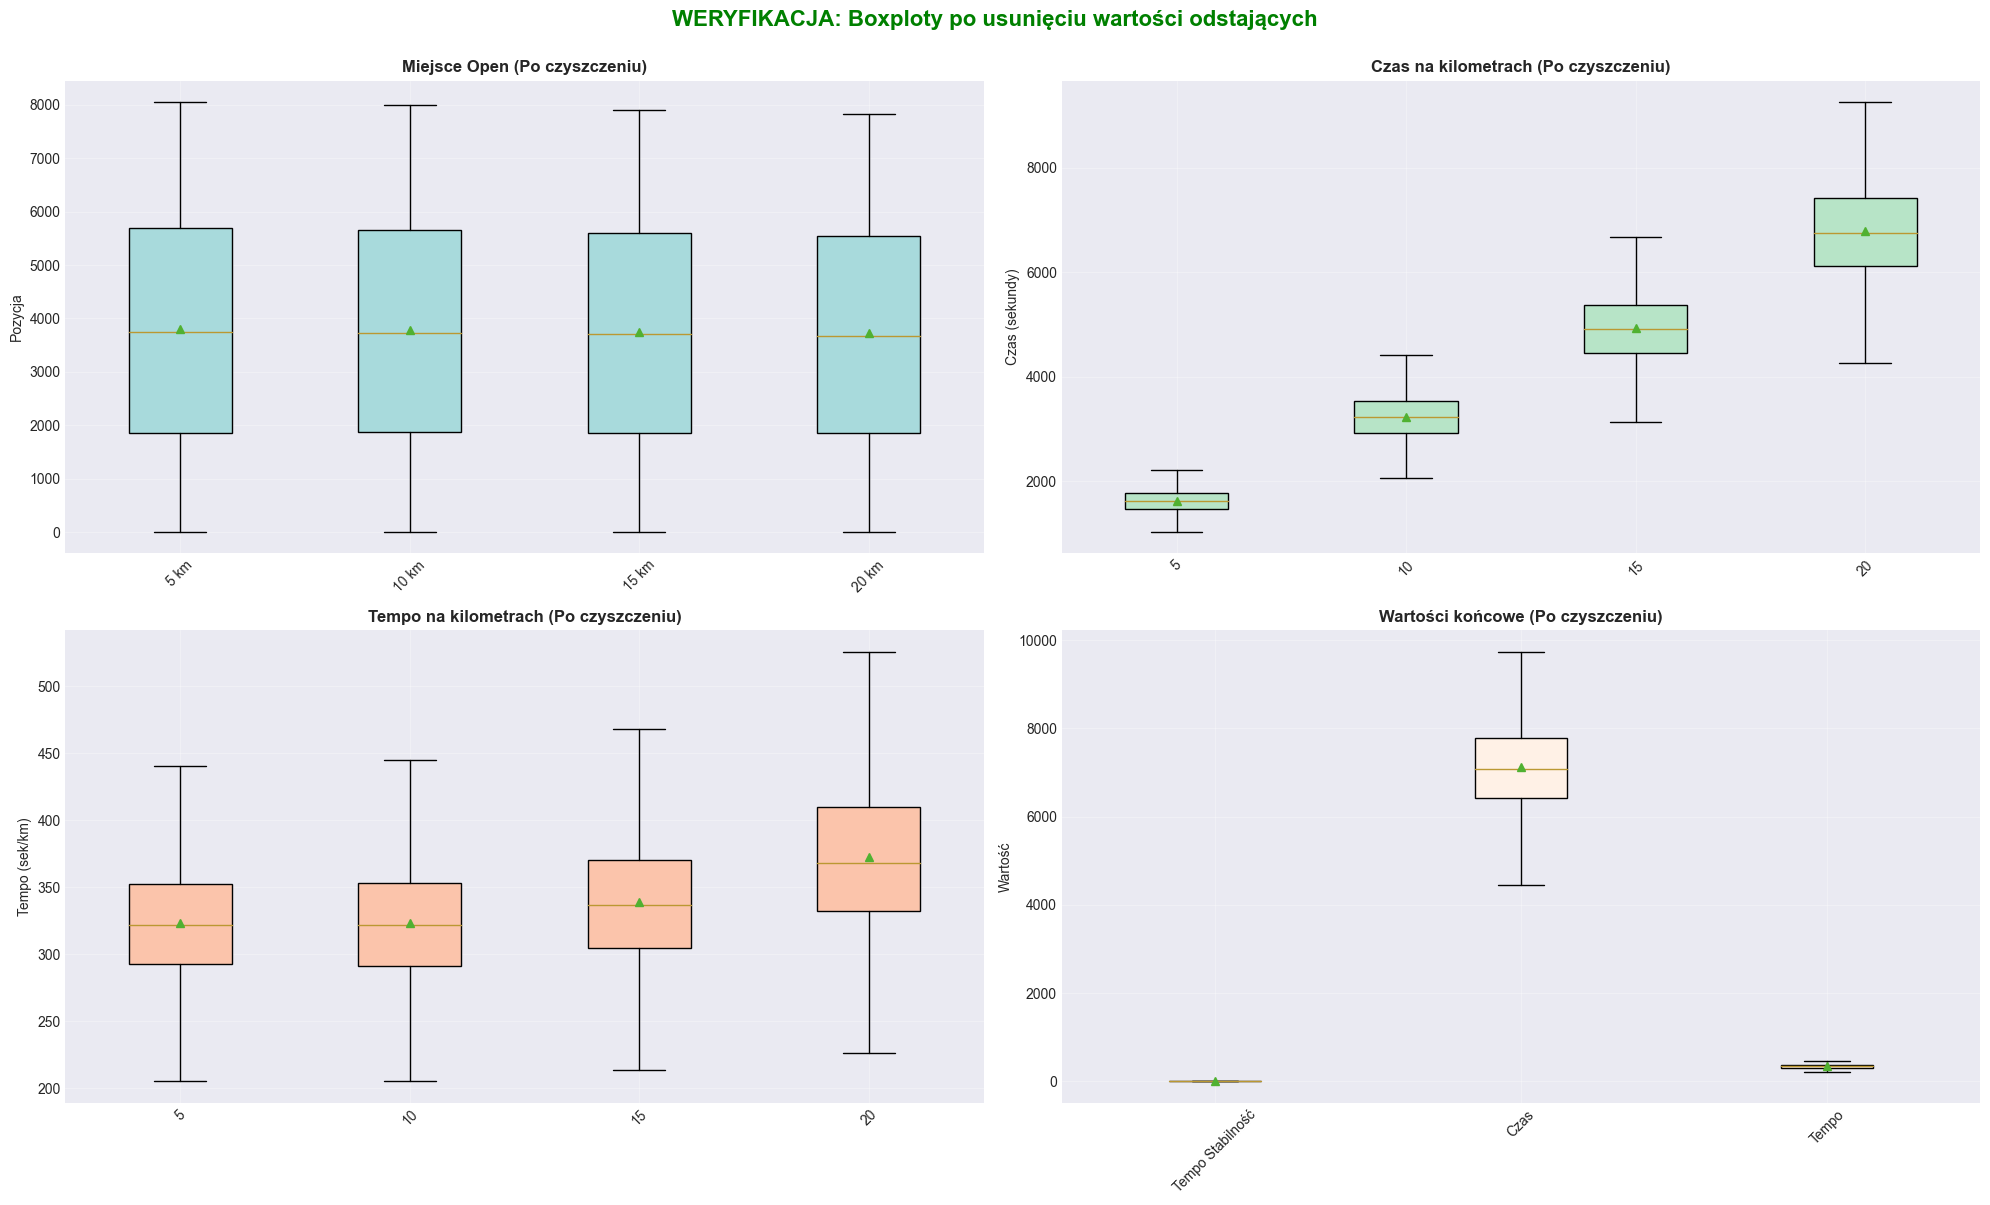


SZCZEGÓŁOWA ANALIZA STATYSTYCZNA (PO CZYSZCZENIU):

            Column   Status Outliers Outlier %     Min     Max
         5 km Czas ✅ CZYSTO        0     0.00% 1029.00 2204.00
 5 km Miejsce Open ✅ CZYSTO        0     0.00%   13.00 8049.00
        5 km Tempo ✅ CZYSTO        0     0.00%  205.80  440.80
        10 km Czas ✅ CZYSTO        0     0.00% 2062.00 4406.00
10 km Miejsce Open ✅ CZYSTO        0     0.00%   13.00 7986.00
       10 km Tempo ✅ CZYSTO        0     0.00%  205.40  445.20
        15 km Czas ✅ CZYSTO        0     0.00% 3131.00 6671.00
15 km Miejsce Open ✅ CZYSTO        0     0.00%   12.00 7909.00
       15 km Tempo ✅ CZYSTO        0     0.00%  213.60  468.20
        20 km Czas ✅ CZYSTO        0     0.00% 4263.00 9261.00
20 km Miejsce Open ✅ CZYSTO        0     0.00%   10.00 7819.00
       20 km Tempo ✅ CZYSTO        0     0.00%  226.40  525.80
  Tempo Stabilność ✅ CZYSTO        0     0.00%   -0.03    0.14
              Czas ✅ CZYSTO        0     0.00% 4456.00 9742.00
  

In [100]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_analyzed = df_without_outliers.copy()

print("=" * 80)
print("ANALIZA BOXPLOT - WERYFIKACJA PO USUNIĘCIU OUTLIERÓW")
print("=" * 80)

kilometer_columns = {
    '5 km': ['5 km Czas', '5 km Miejsce Open', '5 km Tempo'],
    '10 km': ['10 km Czas', '10 km Miejsce Open', '10 km Tempo'],
    '15 km': ['15 km Czas', '15 km Miejsce Open', '15 km Tempo'],
    '20 km': ['20 km Czas', '20 km Miejsce Open', '20 km Tempo']
}

final_columns = ['Tempo Stabilność', 'Czas', 'Tempo']

all_columns_to_plot = []
for km, cols in kilometer_columns.items():
    for col in cols:
        if col in df_analyzed.columns:
            all_columns_to_plot.append(col)

for col in final_columns:
    if col in df_analyzed.columns:
        all_columns_to_plot.append(col)

print(f"\n✓ Znaleziono {len(all_columns_to_plot)} kolumn do weryfikacji w wyczyszczonym zbiorze")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('WERYFIKACJA: Boxploty po usunięciu wartości odstających', fontsize=16, fontweight='bold', color='green', y=1.0)

ax1 = axes[0, 0]
miejsce_cols = [col for col in all_columns_to_plot if 'Miejsce Open' in col]
if miejsce_cols:
    data_miejsce = [df_analyzed[col].dropna() for col in miejsce_cols]
    bp1 = ax1.boxplot(data_miejsce, labels=[col.replace(' Miejsce Open', '') for col in miejsce_cols], 
                        patch_artist=True, showmeans=True)
    ax1.set_title('Miejsce Open (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Pozycja')
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    for patch in bp1['boxes']:
        patch.set_facecolor('#a8dadc')
else:
    ax1.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax1.transAxes)

ax2 = axes[0, 1]
czas_cols = [col for col in all_columns_to_plot if 'km Czas' in col]
if czas_cols:
    data_czas = [df_analyzed[col].dropna() for col in czas_cols]
    bp2 = ax2.boxplot(data_czas, labels=[col.replace(' km Czas', '') for col in czas_cols],
                      patch_artist=True, showmeans=True)
    ax2.set_title('Czas na kilometrach (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Czas (sekundy)')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    for patch in bp2['boxes']:
        patch.set_facecolor('#b7e4c7') 
else:
    ax2.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax2.transAxes)

ax3 = axes[1, 0]
tempo_cols = [col for col in all_columns_to_plot if 'km Tempo' in col]
if tempo_cols:
    data_tempo = [df_analyzed[col].dropna() for col in tempo_cols]
    bp3 = ax3.boxplot(data_tempo, labels=[col.replace(' km Tempo', '') for col in tempo_cols],
                      patch_artist=True, showmeans=True)
    ax3.set_title('Tempo na kilometrach (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Tempo (sek/km)')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=45)
    
    for patch in bp3['boxes']:
        patch.set_facecolor('#fbc4ab')
else:
    ax3.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax3.transAxes)

ax4 = axes[1, 1]
final_cols = [col for col in final_columns if col in all_columns_to_plot]
if final_cols:
    data_final = [df_analyzed[col].dropna() for col in final_cols]
    bp4 = ax4.boxplot(data_final, labels=final_cols, patch_artist=True, showmeans=True)
    ax4.set_title('Wartości końcowe (Po czyszczeniu)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Wartość')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    for patch in bp4['boxes']:
        patch.set_facecolor('#fff1e6') 
else:
    ax4.text(0.5, 0.5, 'Brak danych', ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


print("\n" + "=" * 80)
print("SZCZEGÓŁOWA ANALIZA STATYSTYCZNA (PO CZYSZCZENIU):")
print("=" * 80)

def detect_outliers_iqr(data, column_name):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers, lower_bound, upper_bound, Q1, Q3

outlier_summary = []

for col in all_columns_to_plot:
    data = df_analyzed[col].dropna()
    if len(data) > 0:
        outliers, lower, upper, Q1, Q3 = detect_outliers_iqr(data, col)
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(data)) * 100 if len(data) > 0 else 0
        
      
        status = "✅ CZYSTO" if outlier_count == 0 else f"⚠️ {outlier_count}"
        
        outlier_summary.append({
            'Column': col,
            'Status': status,
            'Total': str(len(data)),
            'Outliers': str(outlier_count),
            'Outlier %': f"{outlier_pct:.2f}%",
            'Min': f"{data.min():.2f}",
            'Max': f"{data.max():.2f}",
            'Lower Bound': f"{lower:.2f}",
            'Upper Bound': f"{upper:.2f}"
        })

if outlier_summary:
    summary_df = pd.DataFrame(outlier_summary)
   
    cols_to_show = ['Column', 'Status', 'Outliers', 'Outlier %', 'Min', 'Max']
    print("\n" + summary_df[cols_to_show].to_string(index=False))
    
    print("\n" + "=" * 80)
    print("PODSUMOWANIE CZYSZCZENIA:")
    print("=" * 80)
    
    total_outliers = sum(int(row['Outliers']) for row in outlier_summary if row['Outliers'].isdigit())
    total_records = sum(int(row['Total']) for row in outlier_summary if row['Total'].isdigit())
    
    print(f"\n✓ Przeanalizowano rekordów: {len(df_analyzed)}")
    print(f"✓ Pozostałe 'statystyczne' outliery: {total_outliers}")
    
    if total_outliers == 0:
        print("\n⭐⭐⭐ SUKCES! ZBIÓR JEST IDEALNIE WYCZYSZCZONY WG KRYTERIUM IQR ⭐⭐⭐")
    else:
        print("\nℹ️ UWAGA: Pojawienie się małej liczby nowych outlierów jest normalne.")
        print("   Po usunięciu skrajnych wartości, rozkład się zwęził (nowe Q1 i Q3),")
        print("   przez co nowe punkty mogą znaleźć się tuż za granicą wąsów.")
        print("   Zazwyczaj nie trzeba ich usuwać w drugiej iteracji.")

else:
    print("\n⚠ Nie znaleziono kolumn do analizy")

In [101]:
df_without_outliers.to_csv('cleaned_halfmarathon_wroclaw_2023.csv', sep=';', index=False)

#### Sprawdźmy jak będzie sobie radził model gdy wyrzucimy te 1784 rekordy z outliersami

In [ ]:
from pycaret.regression import setup, compare_models, predict_model, models


exp_without = setup(
    data=df_without_outliers,
    target='Czas',  
    categorical_features=['Płeć'],
    numeric_features=['Wiek', '5 km Czas'],
    ignore_features=[
        '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
        '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
        '20 km Czas', '20 km Miejsce Open', '20 km Tempo',
        'Miejsce', 'Płeć Miejsce', 'Kategoria wiekowa Miejsce', 
        'Tempo', 'Tempo Stabilność', '5 km Miejsce Open', '5 km Tempo',
        'Rocznik', 'Kategoria wiekowa'
    ],
    # remove_outliers=True,  
    # outliers_threshold=0.05,  
    normalize=True,            
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
    verbose=False
)


In [ ]:
best_models_without = exp_without.compare_models(sort='R2',n_select=3)
tuned_best_models_without = [exp_without.tune_model(m, optimize="MAE") for m in best_models_without]
best_model_without = exp_without.compare_models(best_models_without + tuned_best_models_without, sort="R2")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.6540
lasso,Lasso Regression,230.3209,85652.2625,292.4653,0.9182,0.0395,0.0314,0.4170
ridge,Ridge Regression,230.3071,85649.9262,292.4611,0.9182,0.0395,0.0314,0.0170
lar,Least Angle Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.0180
llar,Lasso Least Angle Regression,230.3208,85652.2561,292.4653,0.9182,0.0395,0.0314,0.0190
br,Bayesian Ridge,230.3035,85649.9175,292.4610,0.9182,0.0395,0.0314,0.0210
gbr,Gradient Boosting Regressor,230.1427,85821.4278,292.7861,0.9180,0.0394,0.0314,0.0540
huber,Huber Regressor,228.7423,86108.0549,293.2641,0.9177,0.0395,0.0311,0.0210
omp,Orthogonal Matching Pursuit,231.0730,86352.4750,293.6587,0.9175,0.0396,0.0315,0.0180
par,Passive Aggressive Regressor,229.2072,88071.6181,296.6124,0.9159,0.0400,0.0311,0.0190


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,242.9069,93456.9228,305.7073,0.9152,0.0409,0.0330
1,242.5647,91544.7533,302.5636,0.9194,0.0411,0.0333
2,225.1918,82080.9772,286.4978,0.9211,0.0382,0.0305
3,226.4219,80689.0866,284.0582,0.9212,0.0384,0.0308
4,220.8816,81338.5024,285.1991,0.9199,0.0381,0.0298
5,221.0419,77919.4141,279.1405,0.9238,0.0382,0.0305
6,218.7219,79755.5452,282.4102,0.9257,0.0377,0.0296
7,238.4095,95305.2225,308.7154,0.9085,0.0420,0.0326
8,224.6587,81740.0089,285.9021,0.9234,0.0387,0.0307


Fitting 10 folds for each of 2 candidates, totalling 20 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,242.9683,93497.3478,305.7734,0.9152,0.0409,0.0330
1,242.5886,91553.1070,302.5774,0.9194,0.0411,0.0333
2,225.2081,82119.0421,286.5642,0.9210,0.0382,0.0305
3,226.4554,80679.4551,284.0413,0.9213,0.0383,0.0308
4,220.8645,81346.5840,285.2132,0.9199,0.0381,0.0298
5,221.0677,77916.5847,279.1354,0.9238,0.0382,0.0305
6,218.7391,79764.2680,282.4257,0.9257,0.0377,0.0296
7,238.3843,95282.1752,308.6781,0.9085,0.0420,0.0326
8,224.6105,81715.6929,285.8596,0.9234,0.0387,0.0307


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,242.9113,93458.3900,305.7096,0.9152,0.0409,0.0330
1,242.5733,91548.3629,302.5696,0.9194,0.0411,0.0333
2,225.1994,82084.9162,286.5047,0.9211,0.0382,0.0305
3,226.4218,80686.7995,284.0542,0.9212,0.0383,0.0308
4,220.8846,81341.3320,285.2040,0.9199,0.0381,0.0298
5,221.0448,77919.6561,279.1409,0.9238,0.0382,0.0305
6,218.7276,79756.6945,282.4123,0.9257,0.0377,0.0296
7,238.4067,95301.2538,308.7090,0.9085,0.0420,0.0326
8,224.6582,81739.0870,285.9005,0.9234,0.0387,0.0307


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
0,Linear Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.0180
1,Lasso Regression,230.3209,85652.2625,292.4653,0.9182,0.0395,0.0314,0.0180
2,Ridge Regression,230.3071,85649.9262,292.4611,0.9182,0.0395,0.0314,0.0240
3,Linear Regression,230.3022,85649.9083,292.4609,0.9182,0.0395,0.0314,0.0180
4,Lasso Regression,230.3114,85650.5405,292.4622,0.9182,0.0395,0.0314,0.0200
5,Ridge Regression,230.3048,85649.9100,292.4610,0.9182,0.0395,0.0314,0.0190


In [ ]:
exp_without.predict_model(best_model_without)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,229.3137,83285.5048,288.5923,0.9182,0.0393,0.0315


,Płeć,5 km Czas,Wiek,Czas,prediction_label
227,M,1243,34.0,5331.0,5342.907228
3862,M,1602,48.0,6990.0,6983.563802
8759,K,2028,30.0,8732.0,8779.757621
5684,M,1744,49.0,7497.0,7598.373342
805,M,1332,35.0,5870.0,5752.843859
...,...,...,...,...,...
9587,K,2116,47.0,9402.0,9183.538928
4716,M,1628,41.0,7188.0,7081.046602
2561,M,1466,35.0,6593.0,6354.779522
7884,K,1906,30.0,8273.0,8272.191425


In [ ]:
# Przykładowe dane od użytkownika
nowe_dane = pd.DataFrame({
    'Płeć': ['K'],          
    'Wiek': [31],          
    '5 km Czas': [1280]     
})


prediction = exp_without.predict_model(best_model_without, data=nowe_dane)


przewidziany_czas = prediction['prediction_label'].iloc[0]
print(f"Twój przewidywany czas na mecie to: {przewidziany_czas} sekund")

Twój przewidywany czas na mecie to: 5539.3330681208 sekund


In [ ]:
from pycaret.regression import setup, compare_models, predict_model, models


exp = setup(
    data=df,
    target='Czas',  
    categorical_features=['Płeć'],
    numeric_features=['Wiek', '5 km Czas'],
    ignore_features=[
        '10 km Czas', '10 km Miejsce Open', '10 km Tempo',
        '15 km Czas', '15 km Miejsce Open', '15 km Tempo',
        '20 km Czas', '20 km Miejsce Open', '20 km Tempo',
        'Miejsce', 'Płeć Miejsce', 'Kategoria wiekowa Miejsce', 
        'Tempo', 'Tempo Stabilność', '5 km Miejsce Open', '5 km Tempo',
        'Rocznik', 'Kategoria wiekowa'
    ],
    # remove_outliers=True,  
    # outliers_threshold=0.05,   
    normalize=True,            
    transformation=True,
    transformation_method='yeo-johnson',
    session_id=123,
    verbose=False
)


In [ ]:
best_models = exp.compare_models(sort='MAE',n_select=4)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,300.8561,175343.2693,418.3599,0.8817,0.0525,0.0390,0.0630
lightgbm,Light Gradient Boosting Machine,305.3317,181347.2751,425.4902,0.8776,0.0534,0.0396,0.2750
par,Passive Aggressive Regressor,308.2734,189888.2724,435.3584,0.8719,0.0549,0.0398,0.0210
huber,Huber Regressor,308.5853,186908.6766,431.9131,0.8739,0.0544,0.0399,0.0270
lasso,Lasso Regression,314.4681,182869.7187,427.3287,0.8766,0.0544,0.0411,0.0200
llar,Lasso Least Angle Regression,314.4683,182869.9267,427.3289,0.8766,0.0544,0.0411,0.0200
ridge,Ridge Regression,314.5289,182896.3161,427.3602,0.8766,0.0544,0.0411,0.0210
br,Bayesian Ridge,314.5327,182896.3463,427.3604,0.8766,0.0544,0.0411,0.0200
lar,Least Angle Regression,314.5355,182896.4007,427.3605,0.8766,0.0544,0.0411,0.0210
lr,Linear Regression,314.5355,182896.4007,427.3605,0.8766,0.0544,0.0411,0.0210


In [ ]:
tuned_best_models = [exp.tune_model(m, optimize="MAE") for m in best_models]
best_model = exp.compare_models(best_models + tuned_best_models, sort="MAE")

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,02:37:30
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,324.1846,205373.0737,453.1811,0.8543,0.0569,0.0426
1,325.4464,222352.0676,471.5422,0.8611,0.0577,0.0416
2,335.8999,216448.6385,465.2404,0.8640,0.0577,0.0431
3,320.0071,191586.6351,437.7061,0.8609,0.0568,0.0426
4,326.7349,206898.3274,454.8608,0.8641,0.0558,0.0415
5,349.8537,233343.9513,483.0569,0.8415,0.0611,0.0449
6,335.4951,242710.5752,492.6567,0.8434,0.0606,0.0428
7,342.9512,218415.3340,467.3493,0.8461,0.0591,0.0444
8,324.8788,194001.9564,440.4565,0.8729,0.0547,0.0423


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,291.6883,167487.2301,409.2520,0.8812,0.0526,0.0386
1,300.4455,191392.3350,437.4841,0.8804,0.0534,0.0386
2,311.5370,178088.2585,422.0050,0.8881,0.0532,0.0405
3,293.9413,155671.1119,394.5518,0.8870,0.0513,0.0391
4,305.6705,175304.0163,418.6932,0.8849,0.0522,0.0392
5,321.7277,192237.5212,438.4490,0.8694,0.0554,0.0414
6,303.4586,211929.6846,460.3582,0.8633,0.0570,0.0391
7,307.9980,183730.8119,428.6383,0.8705,0.0556,0.0403
8,307.8827,171280.6133,413.8606,0.8878,0.0517,0.0401


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,294.1702,173896.4483,417.0089,0.8766,0.0544,0.0387
1,313.7332,210658.4233,458.9754,0.8684,0.0572,0.0404
2,321.4816,191237.2008,437.3068,0.8799,0.0558,0.0417
3,307.1971,166565.6497,408.1246,0.8791,0.0544,0.0410
4,317.9837,193705.9921,440.1204,0.8728,0.0552,0.0406
5,330.4855,211087.2536,459.4423,0.8566,0.0588,0.0425
6,316.5444,225260.1397,474.6158,0.8547,0.0599,0.0407
7,314.7676,195132.8529,441.7384,0.8625,0.0584,0.0413
8,309.3589,177168.1185,420.9134,0.8839,0.0534,0.0403


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,292.4577,170625.2060,413.0680,0.8790,0.0526,0.0382
1,309.1759,208338.3485,456.4410,0.8698,0.0557,0.0394
2,315.1343,188868.9865,434.5906,0.8813,0.0543,0.0405
3,300.7573,162368.2744,402.9495,0.8821,0.0528,0.0398
4,315.2207,194802.6133,441.3645,0.8721,0.0541,0.0399
5,322.4675,204665.3142,452.3995,0.8610,0.0570,0.0412
6,312.8103,220793.7302,469.8869,0.8576,0.0582,0.0398
7,309.1012,189688.1233,435.5320,0.8663,0.0562,0.0401
8,305.8796,177149.1278,420.8909,0.8840,0.0523,0.0394


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
0,Gradient Boosting Regressor,300.8561,175343.2693,418.3599,0.8817,0.0525,0.0390,0.0630
4,Gradient Boosting Regressor,300.8561,175343.2693,418.3599,0.8817,0.0525,0.0390,0.0580
5,Light Gradient Boosting Machine,304.9456,180702.7776,424.7446,0.8780,0.0536,0.0397,0.1460
1,Light Gradient Boosting Machine,305.3317,181347.2751,425.4902,0.8776,0.0534,0.0396,0.2170
7,Huber Regressor,308.0794,189624.9525,435.0147,0.8721,0.0547,0.0397,0.0210
2,Passive Aggressive Regressor,308.2734,189888.2724,435.3584,0.8719,0.0549,0.0398,0.0190
6,Passive Aggressive Regressor,308.2734,189888.2724,435.3584,0.8719,0.0549,0.0398,0.0200
3,Huber Regressor,308.5853,186908.6766,431.9131,0.8739,0.0544,0.0399,0.0200


In [ ]:
exp.predict_model(best_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,303.0731,168851.7425,410.9157,0.8838,0.0522,0.0395


,Płeć,5 km Czas,Wiek,Czas,prediction_label
2015,K,1509,44.0,6409.0,6507.580942
9330,K,1994,26.0,9130.0,8838.184833
7893,M,1872,53.0,8277.0,8279.590853
2611,K,1435,31.0,6609.0,6309.089510
1285,M,1442,45.0,6109.0,6321.717192
...,...,...,...,...,...
3727,M,1572,34.0,6953.0,6809.760854
5701,M,1701,40.0,7502.0,7447.133180
2934,M,1532,42.0,6723.0,6733.744227
1297,M,1493,44.0,6118.0,6512.753351


In [ ]:
# Przykładowe dane od użytkownika
nowe_dane = pd.DataFrame({
    'Płeć': ['M'],          
    'Wiek': [50],          
    '5 km Czas': [1280]     
})


prediction = exp.predict_model(best_model, data=nowe_dane)


przewidziany_czas = prediction['prediction_label'].iloc[0]
print(f"Twój przewidywany czas na mecie to: {przewidziany_czas} sekund")

Twój przewidywany czas na mecie to: 5551.282036093399 sekund


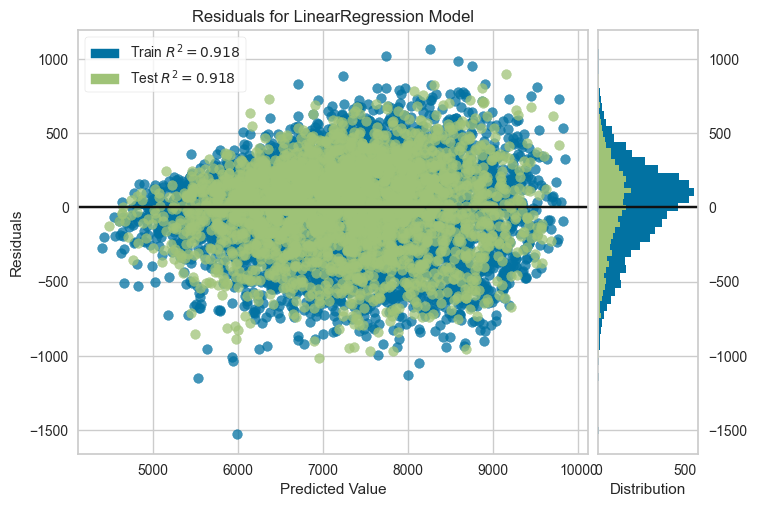

In [ ]:
exp_without.plot_model(best_model_without, plot="residuals")

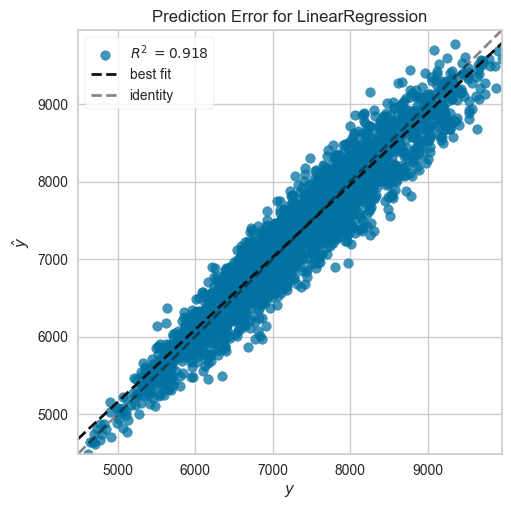

In [ ]:
exp_without.plot_model(best_model_without, plot="error")

In [ ]:
best_final_model = exp_without.finalize_model(best_model_without)
# best_final_model

In [ ]:
exp_without.save_model(best_final_model, "po_final_halfmaraton_model", verbose=False);

## 5. Zapisz model do Digital Ocean Spaces

In [ ]:




BUCKET_NAME = "zad9-domowe"
MODEL_FILENAME = "po_final_halfmaraton_model.pkl"


if os.path.exists(MODEL_FILENAME):
    print(f"\n✅ Znaleziono lokalny plik modelu: {MODEL_FILENAME}")
    
    s3_key_latest = f"models/{MODEL_FILENAME}"
    
    try:
        
        print(f"\n📤 Wysyłam model do bucketu '{BUCKET_NAME}'...")
        s3.upload_file(
            Filename=MODEL_FILENAME,
            Bucket=BUCKET_NAME,
            Key=s3_key_latest
        )
        print(f"✅ Model zapisany jako: {s3_key_latest}")
        
        
        response = s3.head_object(Bucket=BUCKET_NAME, Key=s3_key_latest)
        cloud_size_mb = response['ContentLength'] / (1024 * 1024)
        print(f"\n✅ Weryfikacja: Model w chmurze ma {cloud_size_mb:.2f} MB")
        
  
        
    except Exception as e:
        print(f"\n❌ Błąd podczas wysyłania modelu: {e}")
        
else:
    print(f"\n❌ Nie znaleziono pliku modelu: {MODEL_FILENAME}")
    print("Upewnij się, że model został zapisany lokalnie przed wysłaniem do chmury.")


✅ Znaleziono lokalny plik modelu: po_final_halfmaraton_model.pkl

📤 Wysyłam model do bucketu 'zad9-domowe'...
✅ Model zapisany jako: models/po_final_halfmaraton_model.pkl

✅ Weryfikacja: Model w chmurze ma 0.01 MB
